# Predicting Bridge Maintenance Urgency - Team Ammar, Muntazir, Wasif, Yousuf - (ME sem6)

# loading and preprocessing


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression, RFE
)
from sklearn.inspection import permutation_importance

# Classical ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Install libraries not pre-installed in Colab
!pip install -q kaggle catboost lightgbm shap xgboost imbalanced-learn

import warnings
warnings.filterwarnings('ignore')

# Boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# SHAP for explainability
import shap

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)

In [ ]:
path = "/content/drive/MyDrive/CAPSTONE DATASET/BridgesExport_AllYear.csv"
df_raw = pd.read_csv(path)


In [ ]:
df_raw.shape

(425638, 42)

In [ ]:
df_raw.head()

,Year,1 - State Code,1 - State Name,8 - Structure Number,2022 NBI Structure Number,22 - Owner Agency,3 - County Code,3 - County Name,27 - Year Built,29 - Average Daily Traffic,...,115 - Year of Future Average Daily Traffic,96 - Total Project Cost,Computed - Average Daily Truck Traffic (Volume),Average Relative Humidity,Average Temperature,Maximum Temperature,Minimum Temperature,Mean Wind Speed,City - InfoBridge Place Code,City - InfoBridge Place Name
0,1990,13,Georgia,24300160,24300160,County Highway Agency,243.0,Randolph County,1939.0,660.0,...,2010.0,NaN,46.0,73.0,19.2,39.6,-5.9,0.0,NaN,NaN
1,1990,13,Georgia,13100420,13100420,County Highway Agency,131.0,Grady County,1973.0,270.0,...,2010.0,NaN,11.0,74.0,20.6,40.1,-3.0,0.0,NaN,NaN
2,1990,13,Georgia,13100440,13100440,County Highway Agency,131.0,Grady County,1971.0,270.0,...,2010.0,NaN,19.0,72.0,20.4,39.5,-3.8,1.0,NaN,NaN
3,1990,13,Georgia,6350030,6350030,County Highway Agency,63.0,Clayton County,1961.0,4500.0,...,2010.0,113.0,45.0,75.0,17.1,38.2,-6.6,1.0,NaN,NaN
4,1990,13,Georgia,24300230,24300230,County Highway Agency,243.0,Randolph County,1964.0,240.0,...,2010.0,NaN,17.0,73.0,19.7,39.1,-5.4,2.0,NaN,NaN


In [ ]:
df_raw.tail()

,Year,1 - State Code,1 - State Name,8 - Structure Number,2022 NBI Structure Number,22 - Owner Agency,3 - County Code,3 - County Name,27 - Year Built,29 - Average Daily Traffic,...,115 - Year of Future Average Daily Traffic,96 - Total Project Cost,Computed - Average Daily Truck Traffic (Volume),Average Relative Humidity,Average Temperature,Maximum Temperature,Minimum Temperature,Mean Wind Speed,City - InfoBridge Place Code,City - InfoBridge Place Name
425633,2022,13,Georgia,000000017300180,000000017300180,State Highway Agency,173.0,Lanier County,1945.0,1900.0,...,2032.0,188.0,19.0,NaN,NaN,NaN,NaN,NaN,0.0,No Place Code
425634,2022,13,Georgia,000000017750200,000000017750200,State Highway Agency,177.0,Lee County,2008.0,2830.0,...,2032.0,235.0,28.0,NaN,NaN,NaN,NaN,NaN,45768.0,Leesburg city
425635,2022,13,Georgia,000000015751060,000000015751060,State Highway Agency,157.0,Jackson County,2019.0,2610.0,...,2040.0,29970.0,470.0,NaN,NaN,NaN,NaN,NaN,0.0,No Place Code
425636,2022,13,Georgia,000000018300250,000000018300250,County Highway Agency,183.0,Long County,1954.0,2080.0,...,2032.0,381.0,21.0,NaN,NaN,NaN,NaN,NaN,0.0,No Place Code
425637,2022,13,Georgia,000000016500120,000000016500120,State Highway Agency,165.0,Jenkins County,1937.0,1390.0,...,2031.0,123.0,14.0,NaN,NaN,NaN,NaN,NaN,0.0,No Place Code


In [ ]:
df_raw.dtypes

,0
Year,int64
1 - State Code,int64
1 - State Name,object
8 - Structure Number,object
2022 NBI Structure Number,object
22 - Owner Agency,object
3 - County Code,float64
3 - County Name,object
27 - Year Built,float64
29 - Average Daily Traffic,float64


In [ ]:
# keeping only the years 1998 and onwards(till 2022)

df_raw = df_raw[~df_raw["Year"].between(1990, 1997)]

In [ ]:
df_raw.head()

,Year,1 - State Code,1 - State Name,8 - Structure Number,2022 NBI Structure Number,22 - Owner Agency,3 - County Code,3 - County Name,27 - Year Built,29 - Average Daily Traffic,...,115 - Year of Future Average Daily Traffic,96 - Total Project Cost,Computed - Average Daily Truck Traffic (Volume),Average Relative Humidity,Average Temperature,Maximum Temperature,Minimum Temperature,Mean Wind Speed,City - InfoBridge Place Code,City - InfoBridge Place Name
88632,1998,13,Georgia,000000027300060,000000027300060,State Highway Agency,273.0,Terrell County,1946.0,5900.0,...,2016.0,0.0,944.0,76.0,18.9,38.4,-5.0,2.0,NaN,NaN
88633,1998,13,Georgia,000000001550440,000000001550440,County Highway Agency,15.0,Bartow County,1971.0,4450.0,...,2017.0,297.0,89.0,76.0,16.8,38.3,-6.0,0.0,NaN,NaN
88634,1998,13,Georgia,000000027100440,000000027100440,State Highway Agency,271.0,Telfair County,1974.0,900.0,...,2017.0,0.0,99.0,76.0,19.3,39.0,-4.8,2.0,NaN,NaN
88635,1998,13,Georgia,000000027100470,000000027100470,County Highway Agency,271.0,Telfair County,1994.0,600.0,...,2017.0,0.0,30.0,76.0,19.3,39.0,-4.8,2.0,NaN,NaN
88636,1998,13,Georgia,000000006300220,000000006300220,State Highway Agency,63.0,Clayton County,1976.0,42100.0,...,2016.0,0.0,3368.0,76.0,17.2,37.7,-5.9,1.0,NaN,NaN


In [ ]:
# drop totally irrelevant features
df = df_raw.copy()
df.drop(columns=["1 - State Code", "96 - Total Project Cost", "1 - State Name", "2022 NBI Structure Number","22 - Owner Agency","3 - County Code","3 - County Name","Bridge Age (yr)","City - InfoBridge Place Code","City - InfoBridge Place Name" ], inplace=True)

In [ ]:
# renaming the features

df = df.rename(columns={
    "Year": "year",
    "8 - Structure Number": "bridge_id",
    "27 - Year Built": "year_built",
    "29 - Average Daily Traffic": "adt",
    "43A - Main Span Material": "material",
    "43B - Main Span Design": "design",
    "45 - Number of Spans in Main Unit": "num_spans",
    "49 - Structure Length (ft.)": "length",
    "CAT10 - Bridge Condition": "bridge_condition",
    "CAT29 - Deck Area (sq. ft.)": "deck_area",
    "17 - Longitude (decimal)": "longitude",
    "16 - Latitude (decimal)": "latitude",
    "106 - Year Reconstructed": "year_reconstructed",
    "34 - Skew Angle (degrees)": "skew_angle",
    "48 - Length of Maximum Span (ft.)": "max_span_length",
    "51 - Bridge Roadway Width Curb to Curb (ft.)": "roadway_width",
    "91 - Designated Inspection Frequency": "inspection_freq",
    "58 - Deck Condition Rating": "deck_condition",
    "59 - Superstructure Condition Rating": "super_condition",
    "60 - Substructure Condition Rating": "sub_condition",
    "64 - Operating Rating (US tons)": "operating_rating",
    "66 - Inventory Rating (US tons)": "inventory_rating",
    "30 - Year of Average Daily Traffic": "adt_year",
    "109 - Average Daily Truck Traffic (Percent ADT)": "truck_pct",
    "114 - Future Average Daily Traffic": "future_adt",
    "115 - Year of Future Average Daily Traffic": "future_adt_year",
    "Computed - Average Daily Truck Traffic (Volume)": "truck_volume",
    "Average Relative Humidity": "humidity",
    "Average Temperature": "avg_temp",
    "Maximum Temperature": "max_temp",
    "Minimum Temperature": "min_temp",
    "Mean Wind Speed": "wind_speed"
})

In [ ]:
# Find duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [ ]:
# Find columns with a constant value

constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) == 1]

print("Constant columns:")
for col in constant_cols:
    print(col)

print("\nTotal constant columns:", len(constant_cols))
display(df[constant_cols].head(5))

Constant columns:

Total constant columns: 0


""
88632
88633
88634
88635
88636


# missing values

  Rows: 337,006   Columns: 32


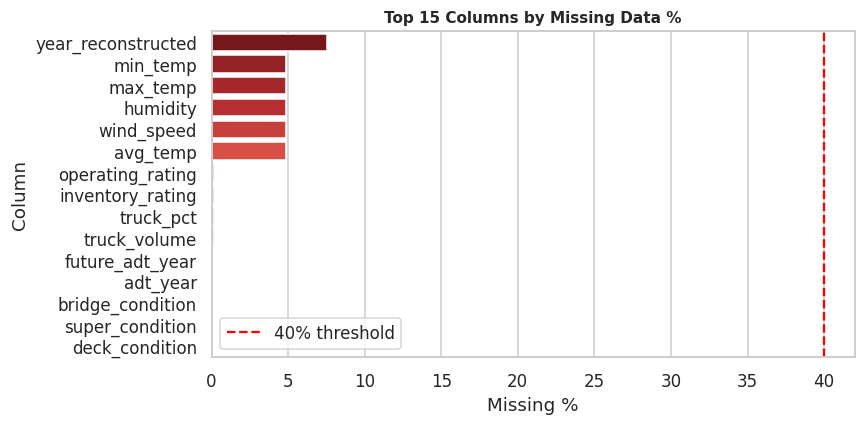


Columns with >40% missing: 0


In [ ]:
# Dataset Shape & Missing Values
print('='*60)
print(f'  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print('='*60)

missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ['Column', 'Missing %']

fig, ax = plt.subplots(figsize=(8, max(4, len(missing_df)*0.15)))
sns.barplot(data=missing_df.head(15), x='Missing %', y='Column', palette='Reds_r', ax=ax)
ax.axvline(40, color='red', linestyle='--', label='40% threshold')
ax.set_title('Top 15 Columns by Missing Data %', fontsize=10, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nColumns with >40% missing: {(missing > 40).sum()}')

In [ ]:
# find missing
missing_counts = df.isnull().sum()
print(missing_counts)

year                      0
bridge_id                 0
year_built                2
adt                       0
material                  0
design                   15
num_spans                14
length                    0
bridge_condition         18
deck_area                 0
longitude                 0
latitude                  0
year_reconstructed    25318
skew_angle               13
max_span_length           0
roadway_width            13
inspection_freq          15
deck_condition           16
super_condition          16
sub_condition            16
operating_rating        598
inventory_rating        596
adt_year                 49
truck_pct               585
future_adt               13
future_adt_year          88
truck_volume            585
humidity              16397
avg_temp              16397
max_temp              16397
min_temp              16397
wind_speed            16397
dtype: int64


In [ ]:
# for finding which other words mean a missing value other than nan

for col in df.columns:
    print(col)
    print(df[col].unique()[:20])
    print("------")

year
[1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017]
------
bridge_id
['000000027300060' '000000001550440' '000000027100440' '000000027100470'
 '000000006300220' '000000001550490' '000000007700320' '000000010550700'
 '000000002700140' '000000022300300' '000000022300340' '000000022300380'
 '000000029500050' '000000029500090' '000000029500120' '000000022300410'
 '000000009350330' '000000002500280' '000000002500330' '000000001501170']
------
year_built
[1946. 1971. 1974. 1994. 1976. 1991. 1973. 1985. 1964. 1966. 1992. 1967.
 1984. 1951. 1941. 1993. 1950. 1965. 1986. 1983.]
------
adt
[ 5900.  4450.   900.   600. 42100.   400. 29170.   580.  4900.  6300.
  2680. 14400.  1400.  2400.  3600.  2160.    90.   810.  5100. 11300.]
------
material
['Concrete' 'Steel' 'Steel Continuous' 'Prestressed Concrete'
 'Wood or Timber' 'Aluminum, Wrought Iron or Cast Iron'
 'Concrete Continuous' 'Prestressed Concrete Continuous' 'Masonry'
 'Other Mater

In [ ]:
df.dtypes

,0
year,int64
bridge_id,object
year_built,float64
adt,float64
material,object
design,object
num_spans,float64
length,float64
bridge_condition,object
deck_area,float64


In [ ]:
# to make '0' count as a missing value only in specific columns

df["num_spans"] = df["num_spans"].replace(0, pd.NA)

df["deck_area"] = df["deck_area"].replace(0, pd.NA)


# removing rows with 'N' condition ratings

df = df[df["deck_condition"] != "N"]

df = df[df["super_condition"] != "N"]

df = df[df["sub_condition"] != "N"]

In [ ]:
# to change data type

df["deck_area"] = pd.to_numeric(df["deck_area"], errors="coerce")

df["num_spans"] = pd.to_numeric(df["num_spans"], errors="coerce")

df["deck_condition"] = pd.to_numeric(df["deck_condition"], errors="coerce")

df["super_condition"] = pd.to_numeric(df["super_condition"], errors="coerce")

df["sub_condition"] = pd.to_numeric(df["sub_condition"], errors="coerce")


In [ ]:
# changing year_reconstructed = 0 to its year_built

mask = df["year_reconstructed"] == 0

df.loc[mask, "year_reconstructed"] = df.loc[mask, "year_built"]

In [ ]:
df["year_reconstructed"].describe()

,year_reconstructed
count,187687.000000
mean,1978.653444
std,18.946025
min,1850.000000
25%,1965.000000
50%,1980.000000
75%,1993.000000
max,2022.000000


In [ ]:
df.shape

(202993, 32)

In [ ]:
df.describe(include='all')

,year,bridge_id,year_built,adt,material,design,num_spans,length,bridge_condition,deck_area,...,adt_year,truck_pct,future_adt,future_adt_year,truck_volume,humidity,avg_temp,max_temp,min_temp,wind_speed
count,202993.000000,202993,202991.000000,202993.000000,202993,202978,202975.000000,202993.000000,202980,2.029800e+05,...,202967.000000,202514.000000,202980.000000,202937.000000,202514.000000,192326.000000,192326.000000,192326.000000,192326.000000,192326.000000
unique,NaN,9360,NaN,NaN,10,17,NaN,NaN,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,CEPSAMGA0000004,NaN,NaN,Concrete,Stringer/Multi-beam or Girder,NaN,NaN,Good,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,31,NaN,NaN,70225,118383,NaN,NaN,102937,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2010.641988,NaN,1974.140351,11797.910366,NaN,NaN,4.267338,221.325708,NaN,1.101567e+04,...,2006.002217,4.284593,17759.276756,2025.975613,574.150148,74.895646,17.482803,38.071212,-7.613265,0.820690
std,7.174055,NaN,20.179219,27729.842804,NaN,NaN,3.814196,337.869030,NaN,2.443538e+04,...,20.019098,6.557472,41799.772200,34.016571,2145.903711,3.269578,1.700203,2.201526,2.648051,0.826986
min,1998.000000,NaN,1850.000000,0.000000,NaN,NaN,1.000000,20.000000,NaN,2.536000e+02,...,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,12.000000,31.000000,-18.600000,0.000000
25%,2005.000000,NaN,1961.000000,600.000000,NaN,NaN,2.000000,98.800000,NaN,3.083200e+03,...,2002.000000,1.000000,900.000000,2022.000000,0.000000,73.000000,16.200000,36.800000,-9.000000,0.000000
50%,2011.000000,NaN,1974.000000,2030.000000,NaN,NaN,3.000000,160.100000,NaN,6.413600e+03,...,2007.000000,1.000000,3030.000000,2027.000000,22.000000,75.000000,17.400000,38.400000,-7.000000,1.000000
75%,2017.000000,NaN,1989.000000,10730.000000,NaN,NaN,5.000000,253.900000,NaN,1.221600e+04,...,2011.000000,6.000000,16050.000000,2031.000000,240.000000,77.000000,18.900000,39.500000,-6.000000,1.000000


In [ ]:
df.dtypes

,0
year,int64
bridge_id,object
year_built,float64
adt,float64
material,object
design,object
num_spans,float64
length,float64
bridge_condition,object
deck_area,float64


In [ ]:
# sorting according to bridge and year to make it a time series dataset

df = df.sort_values(["bridge_id", "year"])

df[["bridge_id", "year"]].head(10)


,bridge_id,year
147470,1GA3906,2002
152729,1GA3906,2003
164255,1GA3906,2004
205866,1GA3906,2007
226142,1GA3906,2008
233080,1GA3906,2009
241765,1GA3906,2010
255884,1GA3906,2011
267326,1GA3906,2012
287422,1GA3906,2013


In [ ]:
# checking how many times a single bridge is repeated

grouped = df.groupby("bridge_id")

df.groupby("bridge_id").size().describe()

,0
count,9360.000000
mean,21.687286
std,6.609348
min,1.000000
25%,23.000000
50%,25.000000
75%,25.000000
max,31.000000


In [ ]:
# removing bridges which are repeated less than 15 times(have data of less than 15 years)

df = df.groupby("bridge_id").filter(lambda x: len(x) >= 15)

#check
grouped = df.groupby("bridge_id")

df.groupby("bridge_id").size().describe()

,0
count,7956.000000
mean,24.231523
std,2.207852
min,15.000000
25%,25.000000
50%,25.000000
75%,25.000000
max,31.000000


In [ ]:
# shape after removing bridges with less data
df.shape

(192786, 32)

In [ ]:
# to make one entry per year per bridge
df_num = df.groupby(["bridge_id", "year"], as_index=False).mean(numeric_only=True)

# categorical: just take first (since they are same)
cat_cols = ["bridge_condition", "material", "design"]

df_cat = df.groupby(["bridge_id", "year"], as_index=False)[cat_cols].first()

# merge
df = df_num.merge(df_cat, on=["bridge_id", "year"])

In [ ]:
missing_counts2 = df.isnull().sum()
print(missing_counts2)

bridge_id                 0
year                      0
year_built                1
adt                       0
num_spans                16
length                    0
deck_area                11
longitude                 0
latitude                  0
year_reconstructed    12875
skew_angle               11
max_span_length           0
roadway_width            11
inspection_freq          13
deck_condition           11
super_condition          11
sub_condition            11
operating_rating        211
inventory_rating        209
adt_year                 18
truck_pct               430
future_adt               11
future_adt_year          53
truck_volume            430
humidity               9243
avg_temp               9243
max_temp               9243
min_temp               9243
wind_speed             9243
bridge_condition         11
material                  0
design                   15
dtype: int64


In [ ]:
# handling features who's missing values are not tolerable

cols_13 = [
    "bridge_condition","operating_rating", "inventory_rating",
    "deck_condition", "inspection_freq",
    "super_condition",
    "sub_condition"]

missing_rows = df[df[cols_13].isnull().any(axis=1)]

print(missing_rows.shape)

# remove those
df = df[~df[cols_13].isnull().any(axis=1)]

(213, 32)


In [ ]:
# handling missing environmental features

env_cols = [
    "humidity",
    "avg_temp",
    "max_temp",
    "min_temp",
    "wind_speed"
]

df["lat_bin"] = df["latitude"].round(1)
df["lon_bin"] = df["longitude"].round(1)

df = df.sort_values(["bridge_id", "year"])

# Fill using each bridge's own history
df[env_cols] = df.groupby("bridge_id")[env_cols].ffill()
df[env_cols] = df.groupby("bridge_id")[env_cols].bfill()

# Fill remaining missing values using nearby bridges in the same year
for col in env_cols:
    df[col] = df.groupby(["year", "lat_bin", "lon_bin"])[col].transform(
        lambda x: x.fillna(x.mean()))

    # filling with global median
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# handling features changing with time only
colss = [ "truck_pct", "truck_volume"]

# Fill remaining missing values using nearby bridges in the same year
for col in colss:
    df[col] = df.groupby(["year"])[col].transform (lambda x: x.fillna(x.mean()))


In [ ]:
# handling consecutive years features

df["adt_year"] = df["adt_year"].fillna(df["year"])
df["future_adt_year"] = df["future_adt_year"].fillna(df["year"] + 1)

In [ ]:
# handling columns which remain same for each bridge every year

cols_to_fill = ["year_built", "num_spans", "design"]

df = df.sort_values(["bridge_id", "year"])

# Forward fill
df[cols_to_fill] = df.groupby("bridge_id")[cols_to_fill].ffill()

# Backward fill
df[cols_to_fill] = df.groupby("bridge_id")[cols_to_fill].bfill()

In [ ]:
# handling missing year_reconstructed feature

df = df.sort_values(["bridge_id", "year"])

# forward fill within each bridge
df["year_reconstructed"] = df.groupby("bridge_id")["year_reconstructed"].ffill()

# remove the ones which are still msising(missing for a bridge in every year)
df = df.dropna(subset=["year_reconstructed"])

In [ ]:
missing_counts3 = df.isnull().sum()
print(missing_counts3)

bridge_id             0
year                  0
year_built            0
adt                   0
num_spans             0
length                0
deck_area             0
longitude             0
latitude              0
year_reconstructed    0
skew_angle            0
max_span_length       0
roadway_width         0
inspection_freq       0
deck_condition        0
super_condition       0
sub_condition         0
operating_rating      0
inventory_rating      0
adt_year              0
truck_pct             0
future_adt            0
future_adt_year       0
truck_volume          0
humidity              0
avg_temp              0
max_temp              0
min_temp              0
wind_speed            0
bridge_condition      0
material              0
design                0
lat_bin               0
lon_bin               0
dtype: int64


In [ ]:
# remove the lat and long groups created earlier
df = df.drop(columns=["lat_bin", "lon_bin"])

In [ ]:
df.shape

(192565, 32)

In [ ]:
# checkin how many different bridges we had

UBR= df_raw["8 - Structure Number"].nunique()
print("Number of bridges at the start: ", UBR)

# checkin how many different bridges we have now

UBN = df["bridge_id"].nunique()
print("Number of bridges now: ", UBN)

Number of bridges at the start:  15034
Number of bridges now:  7956


# eda

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# =========================
# 1. BASIC OVERVIEW
# =========================
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

print("\nSummary Statistics:")
display(df.describe())

Shape: (192565, 32)

Data Types:
 bridge_id              object
year                    int64
year_built            float64
adt                   float64
num_spans             float64
length                float64
deck_area             float64
longitude             float64
latitude              float64
year_reconstructed    float64
skew_angle            float64
max_span_length       float64
roadway_width         float64
inspection_freq       float64
deck_condition        float64
super_condition       float64
sub_condition         float64
operating_rating      float64
inventory_rating      float64
adt_year              float64
truck_pct             float64
future_adt            float64
future_adt_year       float64
truck_volume          float64
humidity              float64
avg_temp              float64
max_temp              float64
min_temp              float64
wind_speed            float64
bridge_condition       object
material               object
design                 object
dtype:

,year,year_built,adt,num_spans,length,deck_area,longitude,latitude,year_reconstructed,skew_angle,...,adt_year,truck_pct,future_adt,future_adt_year,truck_volume,humidity,avg_temp,max_temp,min_temp,wind_speed
count,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,1.925650e+05,192565.000000,192565.000000,192565.000000,192565.000000,...,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000,192565.000000
mean,2010.276483,1972.295838,12037.718085,4.284953,218.439092,1.085716e+04,-83.539306,32.949912,1977.282590,10.444219,...,2005.921367,4.259823,18114.690209,2025.899470,584.849169,74.937027,17.476829,38.045154,-7.503211,0.818616
std,7.131775,18.826349,28218.935646,3.724812,334.542778,2.465768e+04,4.338533,1.966199,18.176616,18.515171,...,7.107983,6.476182,42498.152575,27.932401,2180.151134,3.246430,1.690666,2.178391,2.657032,0.823862
min,1998.000000,1850.000000,0.000000,1.000000,21.000000,2.536000e+02,-86.653110,0.000000,1850.000000,0.000000,...,1900.000000,0.000000,0.000000,0.000000,0.000000,66.000000,12.000000,31.000000,-18.600000,0.000000
25%,2004.000000,1960.000000,600.000000,3.000000,98.800000,3.048800e+03,-84.535610,32.053860,1964.000000,0.000000,...,2002.000000,0.000000,900.000000,2022.000000,0.000000,73.000000,16.200000,36.700000,-9.000000,0.000000
50%,2010.000000,1972.000000,2010.000000,3.000000,160.100000,6.327700e+03,-84.010000,33.280250,1979.000000,0.000000,...,2007.000000,1.000000,3015.000000,2027.000000,22.000000,75.000000,17.300000,38.300000,-7.000000,1.000000
75%,2016.000000,1987.000000,11060.000000,5.000000,252.000000,1.207150e+04,-83.140140,33.921670,1992.000000,17.000000,...,2011.000000,6.000000,16530.000000,2031.000000,241.000000,77.000000,18.900000,39.400000,-5.900000,1.000000
max,2022.000000,2019.000000,415300.000000,85.000000,77799.900000,5.743095e+06,0.000000,84.871520,2021.000000,99.000000,...,2021.000000,99.000000,622950.000000,2118.000000,47355.000000,82.000000,21.600000,44.600000,2.300000,3.000000


In [ ]:
# ============================================================
# Simple EDA Visualizations
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set(style="whitegrid")

# Your target/condition columns
condition_cols = ["deck_condition", "super_condition", "sub_condition"]

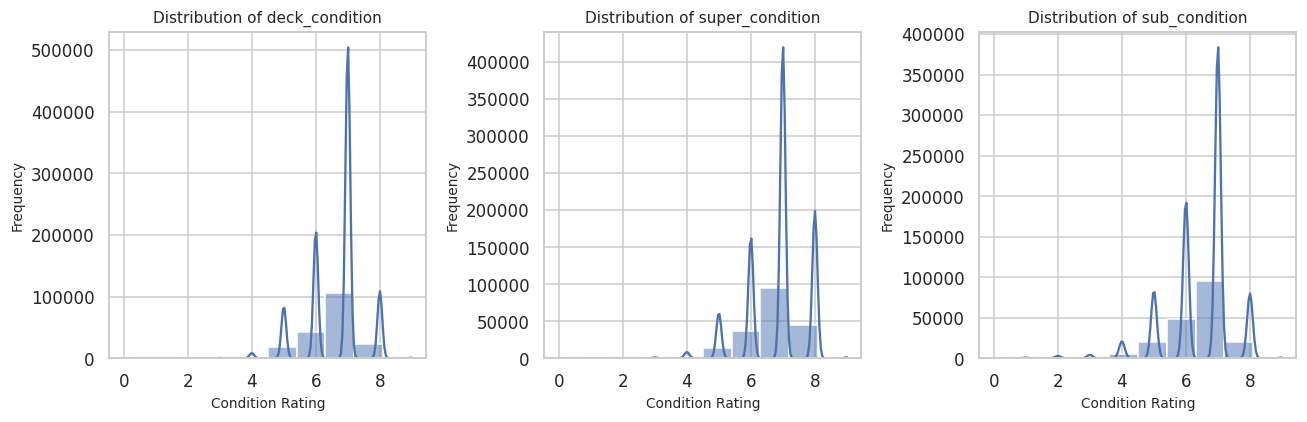

In [ ]:

cols_per_row = 4
n_cols = len(condition_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(16, 4 * n_rows))

# Make axes easy to loop through
axes = axes.flatten()

for i, col in enumerate(condition_cols):
    sns.histplot(df[col], kde=True, bins=10, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
    axes[i].set_xlabel("Condition Rating", fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)

# Remove empty spaces if fewer than 4 graphs
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

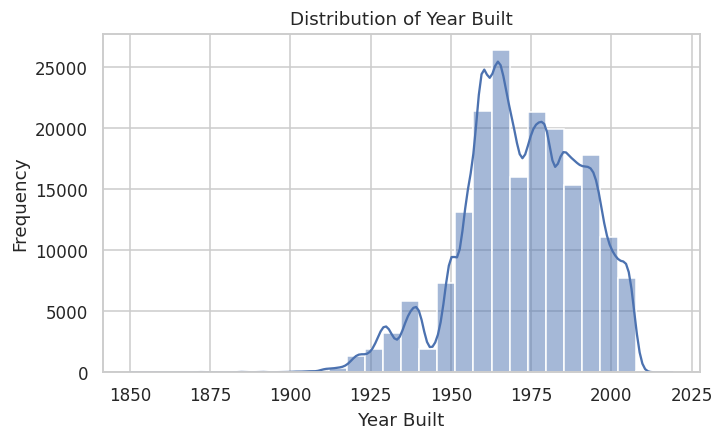

In [ ]:
plt.figure(figsize=(7, 4))
sns.histplot(df["year_built"], kde=True, bins=30)
plt.title("Distribution of Year Built")
plt.xlabel("Year Built")
plt.ylabel("Frequency")


plt.show()

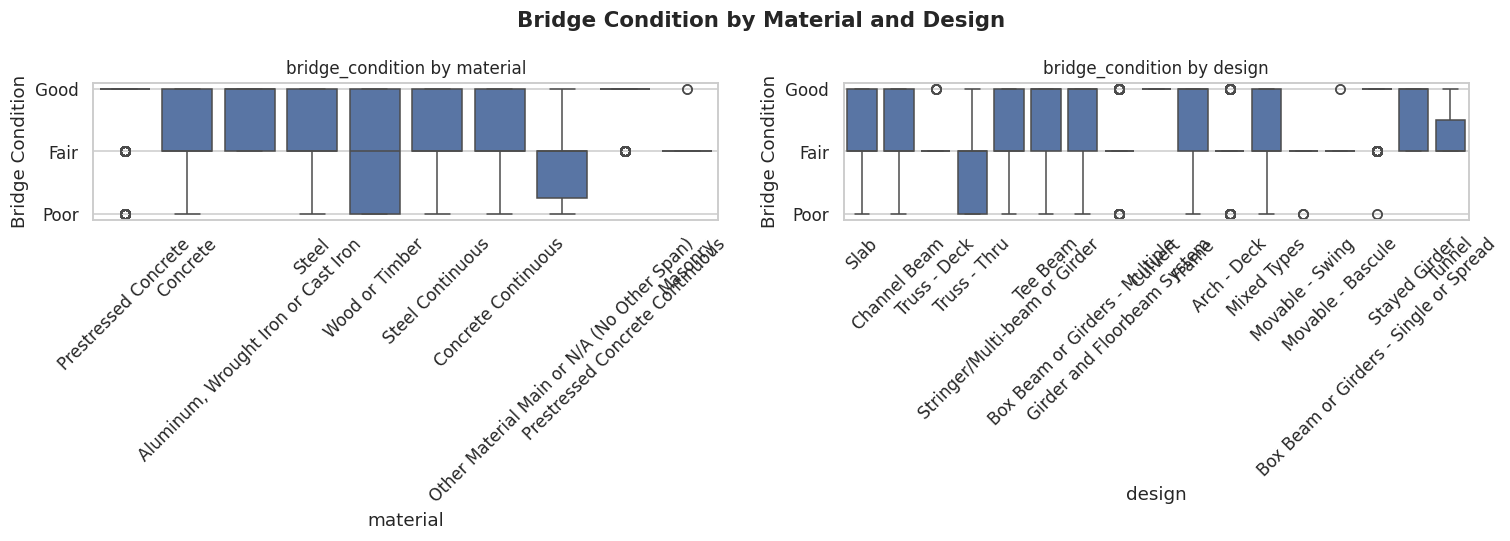

In [ ]:
# bridge condition relation with material and design

categorical_cols = ["material", "design"]
target_col = "bridge_condition"

cols_per_row = 2
n_cols = len(categorical_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(n_rows, cols_per_row, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, cat_col in enumerate(categorical_cols):
    sns.boxplot(x=cat_col, y=target_col, data=df, ax=axes[i])
    axes[i].set_title(f"{target_col} by {cat_col}", fontsize=11)
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel("Bridge Condition")
    axes[i].tick_params(axis="x", rotation=45)

# Remove empty spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Bridge Condition by Material and Design", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

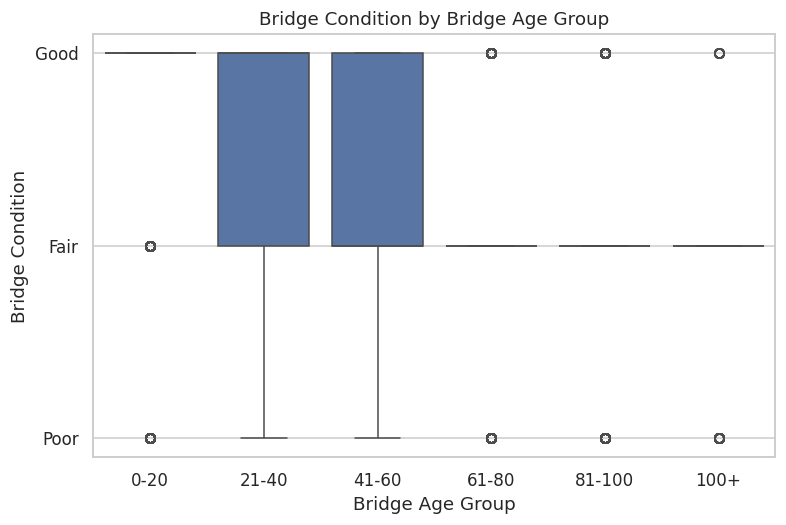

In [ ]:

# Create bridge age
df["bridge_age"] = df["year"] - df["year_built"]

# Create age groups
df["age_group"] = pd.cut(
    df["bridge_age"],
    bins=[0, 20, 40, 60, 80, 100, 200],
    labels=["0-20", "21-40", "41-60", "61-80", "81-100", "100+"]
)

# Boxplot: bridge age group vs bridge condition
plt.figure(figsize=(8, 5))
sns.boxplot(x="age_group", y="bridge_condition", data=df)

plt.title("Bridge Condition by Bridge Age Group")
plt.xlabel("Bridge Age Group")
plt.ylabel("Bridge Condition")
plt.show()

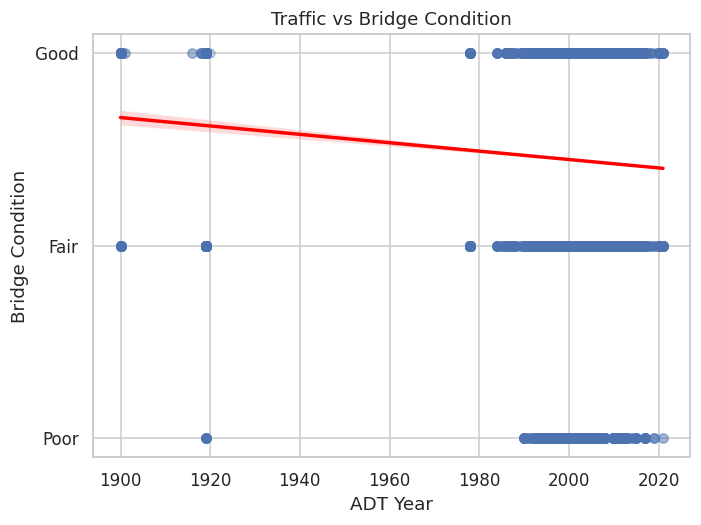

In [ ]:
# Temporary copy only for plotting
plot_df = df[["adt_year", "bridge_condition"]].copy()

# Convert ADT to numeric
plot_df["adt_year"] = pd.to_numeric(plot_df["adt_year"], errors="coerce")

# Map object bridge condition to numeric only for plotting
condition_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2
}

plot_df["bridge_condition_num"] = plot_df["bridge_condition"].map(condition_map)

# Plot
plt.figure(figsize=(7, 5))

sns.regplot(
    x="adt_year",
    y="bridge_condition_num",
    data=plot_df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Traffic vs Bridge Condition")
plt.xlabel("ADT Year")
plt.ylabel("Bridge Condition")

# Show original condition labels on y-axis
plt.yticks(
    [0, 1, 2],
    ["Poor", "Fair", "Good"]
)

plt.show()

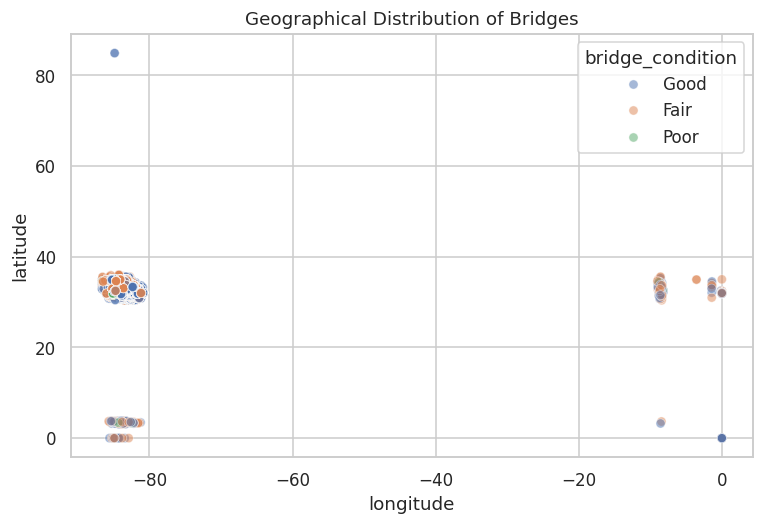

In [ ]:
# =========================
# GEOGRAPHICAL ANALYSIS
# =========================
plt.figure()
sns.scatterplot(data=df, x="longitude", y="latitude", hue="bridge_condition", alpha=0.5)
plt.title("Geographical Distribution of Bridges")
plt.show()

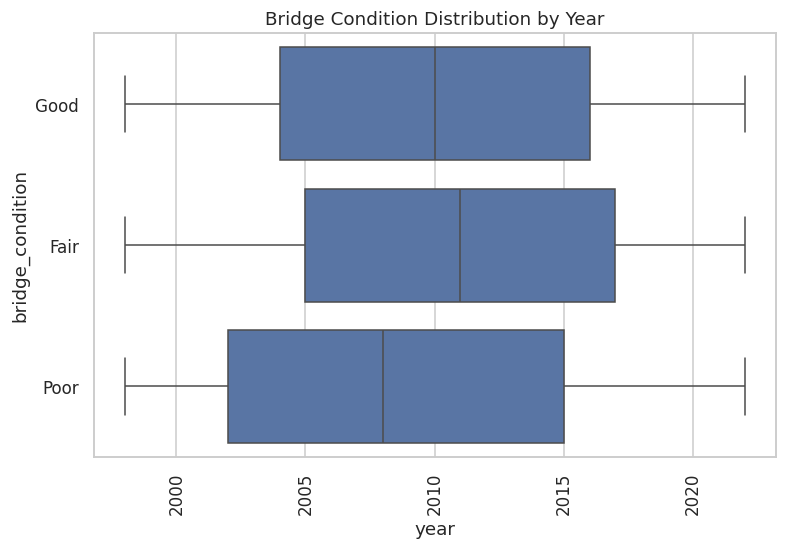

In [ ]:
# =========================
# DISTRIBUTION BY YEAR
# =========================
plt.figure()
sns.boxplot(data=df, x="year", y="bridge_condition")
plt.xticks(rotation=90)
plt.title("Bridge Condition Distribution by Year")
plt.show()

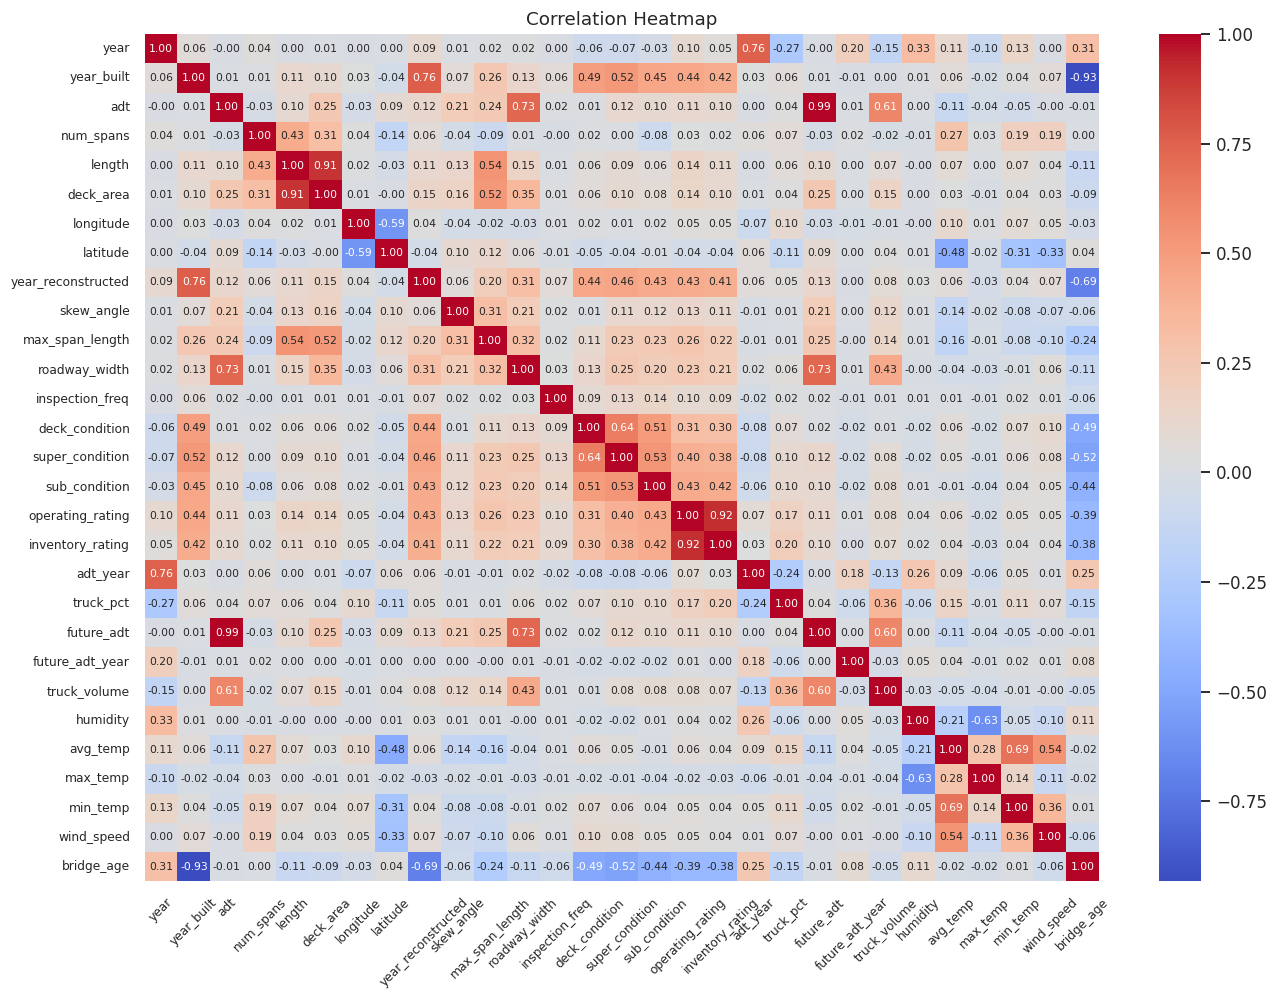

In [ ]:
corr_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, 10))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size": 7}   # font size inside heatmap cells
)

plt.title("Correlation Heatmap", fontsize=12)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8)

plt.show()

# outlier

In [ ]:
from scipy.stats import zscore
import numpy as np

# Step 1: Select numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Step 2: Exclude non-relevant columns
exclude_cols = [
    "bridge_condition",
    "inspection_freq",
    "year", "adt_year", "future_adt_year", "latitude", "longitude","bridge_id"]

clip_cols = [col for col in num_cols if col not in exclude_cols]

# Step 3: Compute Z-scores (optional check)
z_scores = np.abs(df[clip_cols].apply(zscore))

# Step 4: Print outlier counts
print("Outliers before clipping:")
print((z_scores > 3).sum().sort_values(ascending=False))


Outliers before clipping:
roadway_width         5483
truck_pct             4172
future_adt            4042
adt                   3979
truck_volume          3759
skew_angle            3430
max_span_length       2806
num_spans             2715
length                2520
super_condition       2346
inventory_rating      2285
sub_condition         2110
deck_condition        2053
min_temp              1980
deck_area             1780
year_reconstructed    1079
bridge_age             649
year_built             568
avg_temp               226
max_temp               215
operating_rating       133
humidity                 0
wind_speed               0
dtype: int64


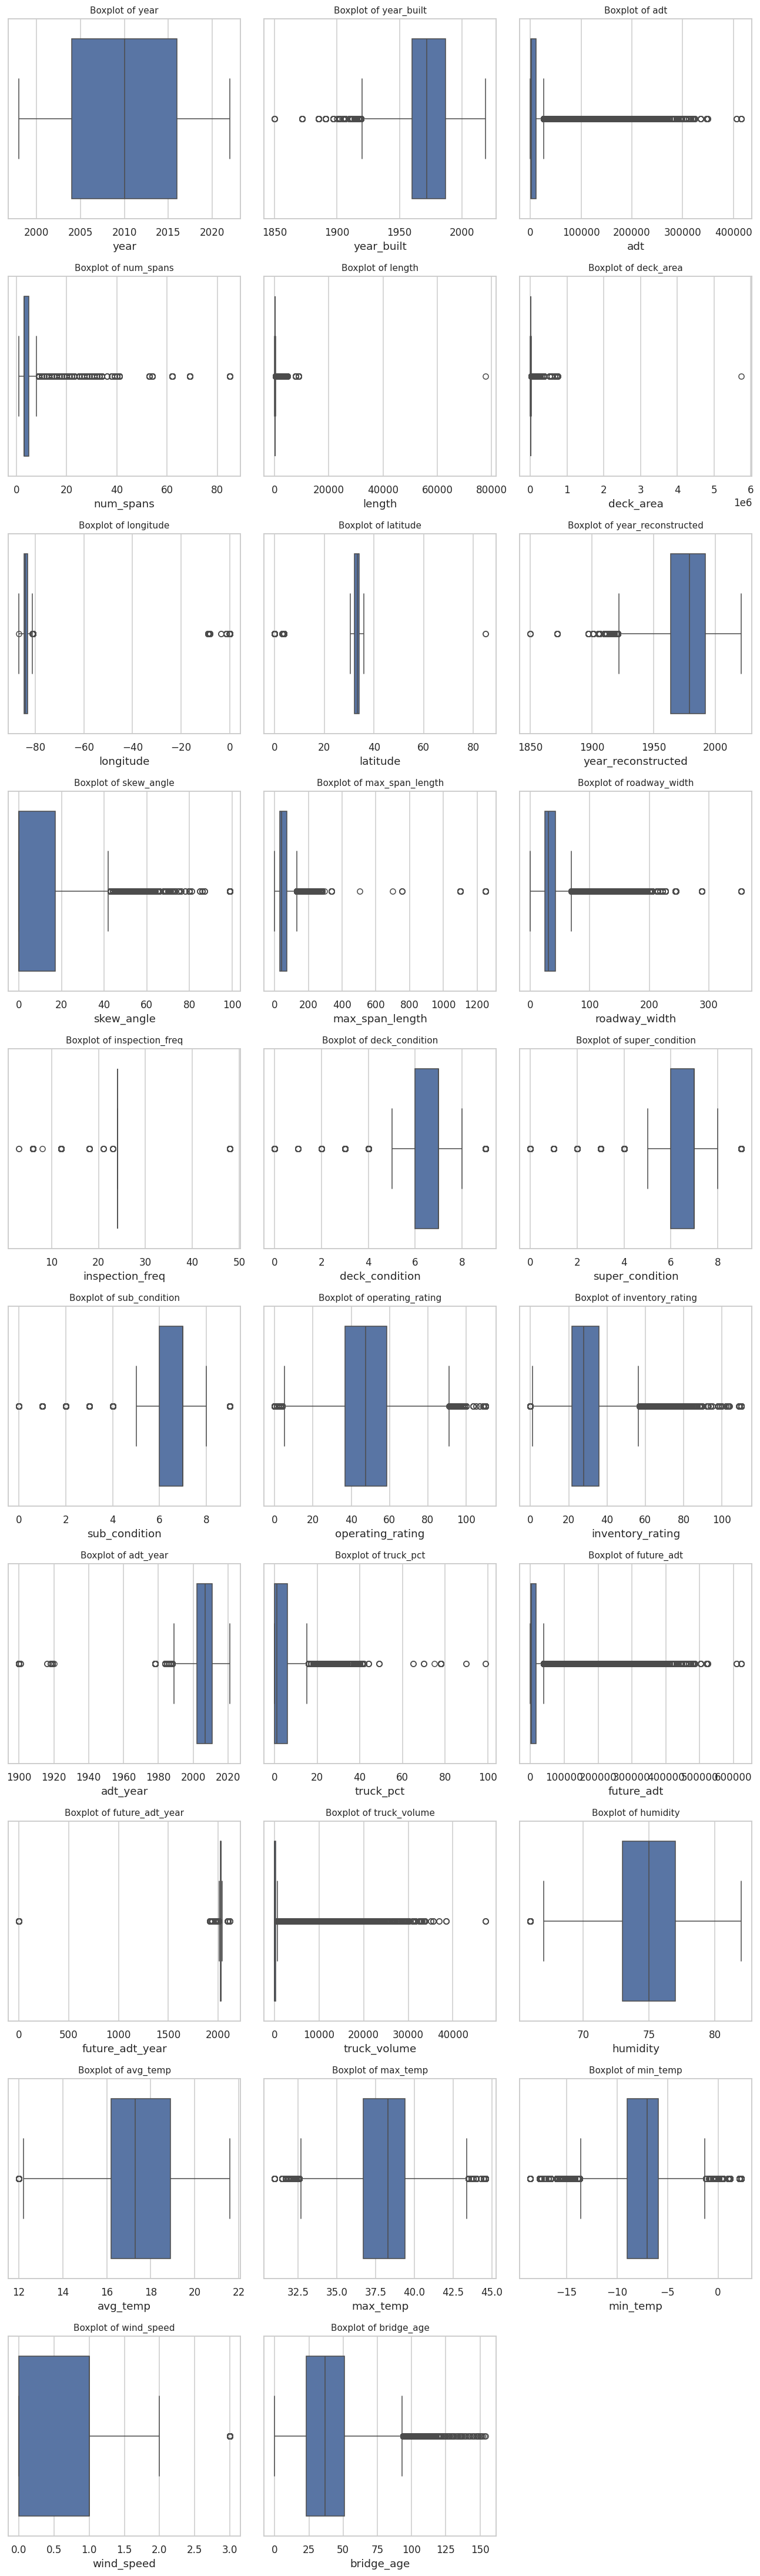

In [ ]:
# =========================
# OUTLIER DETECTION through boxplots
# =========================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

cols_per_row = 3
n_cols = len(num_cols)
n_rows = math.ceil(n_cols / cols_per_row)

fig, axes = plt.subplots(
    n_rows,
    cols_per_row,
    figsize=(12, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=10)
    axes[i].set_xlabel(col)

# Remove empty subplot spaces if num_cols is not divisible by 3
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Step 5: Clip using Z-score
clip_cols = ["adt_year", "future_adt_year", "skew_angle"]   # only columns I want to clip

for col in clip_cols:
    mean = df[col].mean()
    std = df[col].std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    df[col] = np.clip(df[col], lower, upper)

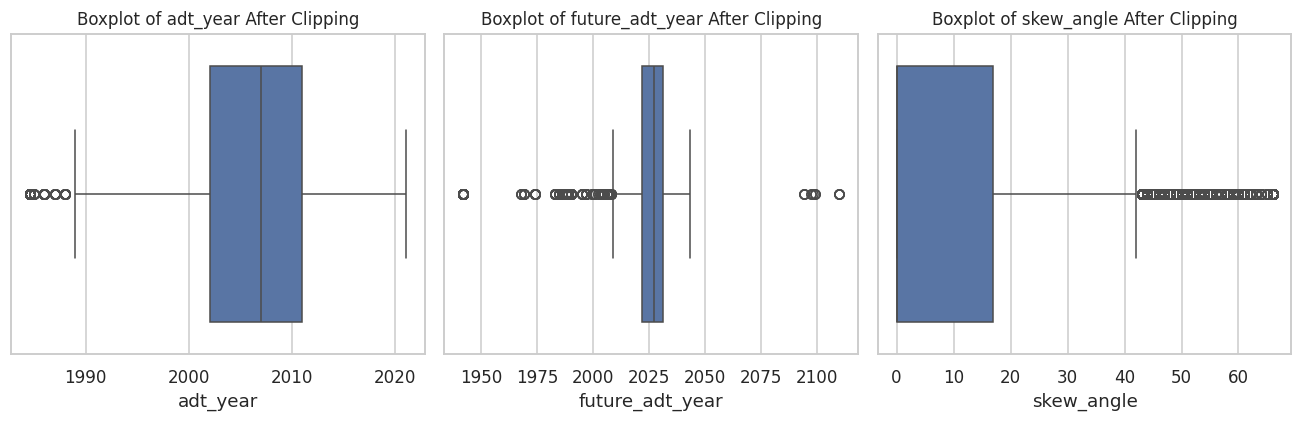

In [ ]:
# Boxplots after clipping

fig, axes = plt.subplots(1, len(clip_cols), figsize=(12, 4))

# If only one column is used, make axes iterable
if len(clip_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, clip_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col} After Clipping", fontsize=11)
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

In [ ]:
#checking if each bridge still has 15 years data
df = df.groupby("bridge_id").filter(lambda x: len(x) >= 15)
df.groupby("bridge_id").size().describe()

,0
count,7943.000000
mean,24.230266
std,2.210693
min,15.000000
25%,25.000000
50%,25.000000
75%,25.000000
max,25.000000


# making data continuous

In [ ]:
# check if each bridge has continuous data

def has_continuous_years(group):
    years = group["year"].sort_values().values
    return (pd.Series(years).diff().dropna() == 1).all()

continuity_check = df.groupby("bridge_id").apply(has_continuous_years)

print(continuity_check.value_counts())

True     7885
False      58
Name: count, dtype: int64


In [ ]:
# including only the bridges with cont. data
def has_continuous_years(group):
    years = group["year"].sort_values().values
    return (pd.Series(years).diff().dropna() == 1).all()

continuous_bridges = df.groupby("bridge_id").filter(has_continuous_years)

df = continuous_bridges.copy()

# verify
df.groupby("bridge_id")["year"].apply(
    lambda x: x.sort_values().diff().dropna().eq(1).all()
).value_counts()

,count
year,
True,7885


In [ ]:
df.shape

(191255, 34)

# Feature Engineering

In [ ]:
# ── Feature Engineering ──────────────────────────────────────────────────

# 1. Log-transform traffic columns
df["log_adt"] = np.log1p(df["adt"])
df["log_future_adt"] = np.log1p(df["future_adt"])
df["log_truck_volume"] = np.log1p(df["truck_volume"].fillna(0))


# 2. Effective age, Since every row has reconstruction year, use year_reconstructed

df["effective_age"] = df["year"] - df["year_reconstructed"]
df["effective_age"] = df["effective_age"].clip(0, 300)


# 3. Bridge age based only on original construction year
df["bridge_age"] = df["year"] - df["year_built"]
df["bridge_age"] = df["bridge_age"].clip(0, 300)


# 4. Temperature range
df["temp_range"] = df["max_temp"] - df["min_temp"]


# 5. Composite condition columns
condition_cols = ["deck_condition", "super_condition", "sub_condition"]

df["min_condition"] = df[condition_cols].min(axis=1)
df["mean_condition"] = df[condition_cols].mean(axis=1)


# 6. ENCODING Bridge condition as ordinal
# Keeps bridge_condition as object, creates numeric version separately
condition_map = {
    "Poor": 0,
    "Fair": 1,
    "Good": 2
}

df["bridge_condition_ord"] = df["bridge_condition"].map(condition_map)


# 7. ENCODING categorical features
categorical_cols = ["material", "design"]

for col in categorical_cols:
    df[col + "_enc"] = df[col].astype("category").cat.codes

# Target construction

This section creates future condition targets. The current bridge-year record is used to predict the bridge condition after a fixed forecast horizon.

The main forecast horizon used here is 5 years.

In [ ]:
# ── Target Construction ──────────────────────────────────────────────────

FORECAST_YEARS = 5

# Make sure data is sorted as a time-series panel
_df = df.sort_values(["bridge_id", "year"]).copy()

# Future condition table: bridge_id + future year + future component ratings
future_lookup = _df[[
    "bridge_id", "year", "deck_condition", "super_condition", "sub_condition"
]].copy()

future_lookup = future_lookup.rename(columns={
    "year": "target_year",
    "deck_condition": "deck_condition_future",
    "super_condition": "super_condition_future",
    "sub_condition": "sub_condition_future"
})

# For each current row, target_year is current year + FORECAST_YEARS
_df["target_year"] = _df["year"] + FORECAST_YEARS

# Merge future targets back to current rows
df_model_base = _df.merge(
    future_lookup,
    on=["bridge_id", "target_year"],
    how="left"
)

target_cols = [
    "deck_condition_future",
    "super_condition_future",
    "sub_condition_future"
]

print("Future target construction complete")
print("Forecast horizon:", FORECAST_YEARS, "years")
print("Rows before target filtering:", df_model_base.shape[0])
print("Rows with all three future targets:", df_model_base[target_cols].notna().all(axis=1).sum())
print("Target coverage (%):", round(df_model_base[target_cols].notna().all(axis=1).mean() * 100, 2))

display(df_model_base[["bridge_id", "year", "target_year"] + target_cols].head())

Future target construction complete
Forecast horizon: 5 years
Rows before target filtering: 191255
Rows with all three future targets: 151830
Target coverage (%): 79.39


,bridge_id,year,target_year,deck_condition_future,super_condition_future,sub_condition_future
0,2GA1475,2006,2011,5.0,7.0,6.0
1,2GA1475,2007,2012,5.0,7.0,6.0
2,2GA1475,2008,2013,5.0,7.0,6.0
3,2GA1475,2009,2014,6.0,6.0,6.0
4,2GA1475,2010,2015,6.0,6.0,6.0


# Modeling dataframe

The model uses your engineered features and the original cleaned variables from your dataset. `future_adt` and `log_future_adt` are kept because they are treated as agency-provided projected traffic variables available in the original dataset, not values generated by shifting observed future records.

In [ ]:
# ── Build Modeling Dataframe ───────────────────────────────────────────────

candidate_features = [
    # Current condition variables
    "deck_condition",
    "super_condition",
    "sub_condition",
    "min_condition",
    "mean_condition",
    "bridge_condition_ord",

    # Age variables
    "effective_age",
    "bridge_age",

    # Traffic variables
    "adt",
    "log_adt",
    "future_adt",
    "log_future_adt",
    "truck_pct",
    "truck_volume",
    "log_truck_volume",

    # Structural variables
    "num_spans",
    "length",
    "deck_area",
    "skew_angle",
    "max_span_length",
    "roadway_width",
    "inspection_freq",
    "operating_rating",
    "inventory_rating",

    # Climate variables
    "humidity",
    "avg_temp",
    "max_temp",
    "min_temp",
    "temp_range",
    "wind_speed",

    # Encoded categorical variables
    "material_enc",
    "design_enc"
]

# Keep only features that actually exist in your dataframe
features = [col for col in candidate_features if col in df_model_base.columns]
missing_features = [col for col in candidate_features if col not in df_model_base.columns]

id_cols = ["bridge_id", "year", "target_year"]
model_df = df_model_base[id_cols + features + target_cols].copy()

# Keep rows where all future targets are available
model_df = model_df.dropna(subset=target_cols).copy()

print("Available features used:", len(features))
print(features)
print("\nCandidate features not found and skipped:", missing_features)
print("\nModel dataframe shape:", model_df.shape)
display(model_df.head())

Available features used: 32
['deck_condition', 'super_condition', 'sub_condition', 'min_condition', 'mean_condition', 'bridge_condition_ord', 'effective_age', 'bridge_age', 'adt', 'log_adt', 'future_adt', 'log_future_adt', 'truck_pct', 'truck_volume', 'log_truck_volume', 'num_spans', 'length', 'deck_area', 'skew_angle', 'max_span_length', 'roadway_width', 'inspection_freq', 'operating_rating', 'inventory_rating', 'humidity', 'avg_temp', 'max_temp', 'min_temp', 'temp_range', 'wind_speed', 'material_enc', 'design_enc']

Candidate features not found and skipped: []

Model dataframe shape: (151830, 38)


,bridge_id,year,target_year,deck_condition,super_condition,sub_condition,min_condition,mean_condition,bridge_condition_ord,effective_age,...,avg_temp,max_temp,min_temp,temp_range,wind_speed,material_enc,design_enc,deck_condition_future,super_condition_future,sub_condition_future
0,2GA1475,2006,2011,6.0,7.0,6.0,6.0,6.333333,1,49.0,...,19.7,39.4,-5.7,45.1,2.0,1,3,5.0,7.0,6.0
1,2GA1475,2007,2012,6.0,7.0,6.0,6.0,6.333333,1,50.0,...,19.6,40.9,-5.8,46.7,2.0,1,3,5.0,7.0,6.0
2,2GA1475,2008,2013,5.0,7.0,6.0,5.0,6.000000,1,51.0,...,18.5,38.4,-6.3,44.7,2.0,1,3,5.0,7.0,6.0
3,2GA1475,2009,2014,5.0,7.0,6.0,5.0,6.000000,1,52.0,...,18.3,35.9,-6.3,42.2,2.0,1,3,6.0,6.0,6.0
4,2GA1475,2010,2015,5.0,7.0,6.0,5.0,6.000000,1,53.0,...,18.2,39.0,-6.8,45.8,2.0,1,3,6.0,6.0,6.0


# Feature selection

This section follows your friend's idea: first use mutual information to identify useful predictors, then use Random Forest feature importance to keep the strongest features for the main classical ML models.

Mutual information ranking:


,feature,mutual_information
17,deck_area,0.543945
0,deck_condition,0.505547
4,mean_condition,0.328862
3,min_condition,0.262903
5,bridge_condition_ord,0.189577
1,super_condition,0.182465
7,bridge_age,0.152414
10,future_adt,0.141464
11,log_future_adt,0.140511
8,adt,0.139689


Random Forest feature importance ranking:


,feature,importance
1,deck_condition,0.805011
25,truck_pct,0.021608
6,bridge_age,0.016871
23,avg_temp,0.015301
10,roadway_width,0.012501
0,deck_area,0.010666
13,effective_age,0.010269
24,min_temp,0.008469
20,max_span_length,0.008418
22,temp_range,0.008146


Final selected features: 12
['deck_condition', 'truck_pct', 'bridge_age', 'avg_temp', 'roadway_width', 'deck_area', 'effective_age', 'min_temp', 'max_span_length', 'temp_range', 'operating_rating', 'length']


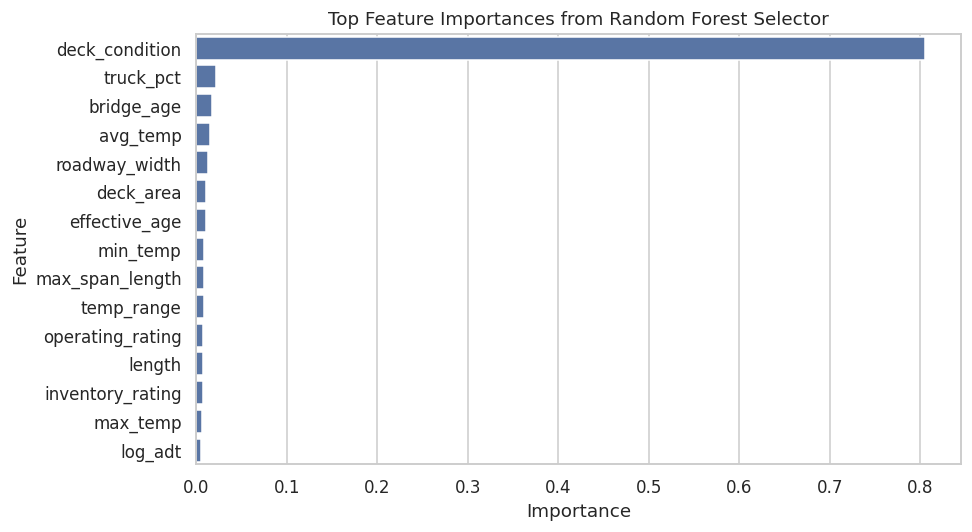

In [ ]:
# ── Feature Selection ─────────────────────────────────────────────────────

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

feature_selection_target = "deck_condition_future"

X_fs = model_df[features].copy()
y_fs = model_df[feature_selection_target].copy()

# Impute missing values before feature selection
fs_imputer = SimpleImputer(strategy="median")
X_fs_imp = pd.DataFrame(
    fs_imputer.fit_transform(X_fs),
    columns=features,
    index=X_fs.index
)

# Mutual information
mi_scores = mutual_info_regression(X_fs_imp, y_fs, random_state=SEED)
mi_df = pd.DataFrame({
    "feature": features,
    "mutual_information": mi_scores
}).sort_values("mutual_information", ascending=False)

print("Mutual information ranking:")
display(mi_df)

# Keep features with non-zero MI. If too few survive, keep the top 15.
mi_selected = mi_df.loc[mi_df["mutual_information"] > 0, "feature"].tolist()
if len(mi_selected) < 8:
    mi_selected = mi_df.head(min(15, len(mi_df)))["feature"].tolist()

# Random Forest feature importance on MI-selected features
rf_selector = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=SEED,
    n_jobs=-1
)
rf_selector.fit(X_fs_imp[mi_selected], y_fs)

rf_importance_df = pd.DataFrame({
    "feature": mi_selected,
    "importance": rf_selector.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest feature importance ranking:")
display(rf_importance_df)

# Final features: keep top 12, or fewer if fewer exist
N_FINAL_FEATURES = min(12, len(rf_importance_df))
final_features = rf_importance_df.head(N_FINAL_FEATURES)["feature"].tolist()

print("Final selected features:", len(final_features))
print(final_features)

plt.figure(figsize=(9, 5))
sns.barplot(data=rf_importance_df.head(15), x="importance", y="feature")
plt.title("Top Feature Importances from Random Forest Selector")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Temporal train, validation, and holdout split

The model is trained on earlier years and tested on later years. This is more realistic for future bridge condition prediction than a fully random split.

In [ ]:
# ── Temporal Split ────────────────────────────────────────────────────────

HOLDOUT_START_YEAR = 2014

trainval_df = model_df[model_df["year"] < HOLDOUT_START_YEAR].copy()
holdout_df = model_df[model_df["year"] >= HOLDOUT_START_YEAR].copy()

train_df, val_df = train_test_split(
    trainval_df,
    test_size=0.20,
    random_state=SEED
)

print("Train years:", train_df["year"].min(), "to", train_df["year"].max())
print("Validation years:", val_df["year"].min(), "to", val_df["year"].max())
print("Holdout years:", holdout_df["year"].min(), "to", holdout_df["year"].max())
print("\nRows:")
print("Train:", train_df.shape[0])
print("Validation:", val_df.shape[0])
print("Holdout:", holdout_df.shape[0])

X_train_raw = train_df[final_features]
X_val_raw = val_df[final_features]
X_holdout_raw = holdout_df[final_features]

# Imputation is fit only on training data
model_imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(model_imputer.fit_transform(X_train_raw), columns=final_features, index=train_df.index)
X_val_imp = pd.DataFrame(model_imputer.transform(X_val_raw), columns=final_features, index=val_df.index)
X_holdout_imp = pd.DataFrame(model_imputer.transform(X_holdout_raw), columns=final_features, index=holdout_df.index)

# Scaling is needed for Ridge and KNN
model_scaler = StandardScaler()
X_train_scaled = pd.DataFrame(model_scaler.fit_transform(X_train_imp), columns=final_features, index=train_df.index)
X_val_scaled = pd.DataFrame(model_scaler.transform(X_val_imp), columns=final_features, index=val_df.index)
X_holdout_scaled = pd.DataFrame(model_scaler.transform(X_holdout_imp), columns=final_features, index=holdout_df.index)

print("\nSelected modeling features:")
print(final_features)

Train years: 1998 to 2013
Validation years: 1998 to 2013
Holdout years: 2014 to 2017

Rows:
Train: 96234
Validation: 24059
Holdout: 31537

Selected modeling features:
['deck_condition', 'truck_pct', 'bridge_age', 'avg_temp', 'roadway_width', 'deck_area', 'effective_age', 'min_temp', 'max_span_length', 'temp_range', 'operating_rating', 'length']


# Classical ML models

The following models are trained and compared:

- Ridge Regression
- Decision Tree
- Random Forest
- KNN
- XGBoost
- LightGBM


In [ ]:
# ── Classical ML Model Setup ──────────────────────────────────────────────

from sklearn.base import clone

NEEDS_SCALING = {"Ridge", "KNN"}

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse_score(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

model_templates = {
    "Ridge": Ridge(alpha=1.0, random_state=SEED),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=SEED),
    "Random Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=16,
        min_samples_leaf=5,
        random_state=SEED,
        n_jobs=-1
    ),
    "KNN": KNeighborsRegressor(n_neighbors=15, weights="distance"),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=SEED,
        n_jobs=-1,
        verbose=-1
    )
}

print("Models included:")
for name in model_templates:
    print("-", name)

Models included:
- Ridge
- Decision Tree
- Random Forest
- KNN
- XGBoost
- LightGBM


In [ ]:
# ── Train and Compare Classical Models for Deck Future Condition ──────────

deck_target = "deck_condition_future"
y_train_deck = train_df[deck_target]
y_val_deck = val_df[deck_target]
y_holdout_deck = holdout_df[deck_target]

trained_deck_models = {}
deck_results = []
deck_predictions_val = {}
deck_predictions_holdout = {}

for name, template in model_templates.items():
    model = clone(template)

    if name in NEEDS_SCALING:
        Xtr, Xva, Xho = X_train_scaled, X_val_scaled, X_holdout_scaled
    else:
        Xtr, Xva, Xho = X_train_imp, X_val_imp, X_holdout_imp

    model.fit(Xtr, y_train_deck)

    val_pred = model.predict(Xva)
    holdout_pred = model.predict(Xho)

    trained_deck_models[name] = model
    deck_predictions_val[name] = val_pred
    deck_predictions_holdout[name] = holdout_pred

    val_metrics = regression_metrics(y_val_deck, val_pred)
    holdout_metrics = regression_metrics(y_holdout_deck, holdout_pred)

    deck_results.append({
        "Model": name,
        "Val_MAE": val_metrics["MAE"],
        "Val_RMSE": val_metrics["RMSE"],
        "Val_R2": val_metrics["R2"],
        "Holdout_MAE": holdout_metrics["MAE"],
        "Holdout_RMSE": holdout_metrics["RMSE"],
        "Holdout_R2": holdout_metrics["R2"]
    })

deck_results_df = pd.DataFrame(deck_results).sort_values("Val_MAE").reset_index(drop=True)
print("Deck condition model comparison:")
display(deck_results_df)

best_deck_model_name = deck_results_df.loc[0, "Model"]
print("Best deck model by validation MAE:", best_deck_model_name)

Deck condition model comparison:


,Model,Val_MAE,Val_RMSE,Val_R2,Holdout_MAE,Holdout_RMSE,Holdout_R2
0,Random Forest,0.237173,0.402466,0.771754,0.433189,0.645439,0.123789
1,KNN,0.253076,0.432903,0.735925,0.424824,0.646003,0.122256
2,LightGBM,0.268332,0.429997,0.739460,0.427921,0.645912,0.122502
3,Decision Tree,0.272105,0.452741,0.711168,0.430006,0.656038,0.094774
4,XGBoost,0.272413,0.435835,0.732337,0.426924,0.644372,0.126681
5,Ridge,0.325929,0.484139,0.669719,0.433074,0.624674,0.179259


Best deck model by validation MAE: Random Forest


# Model comparison plots

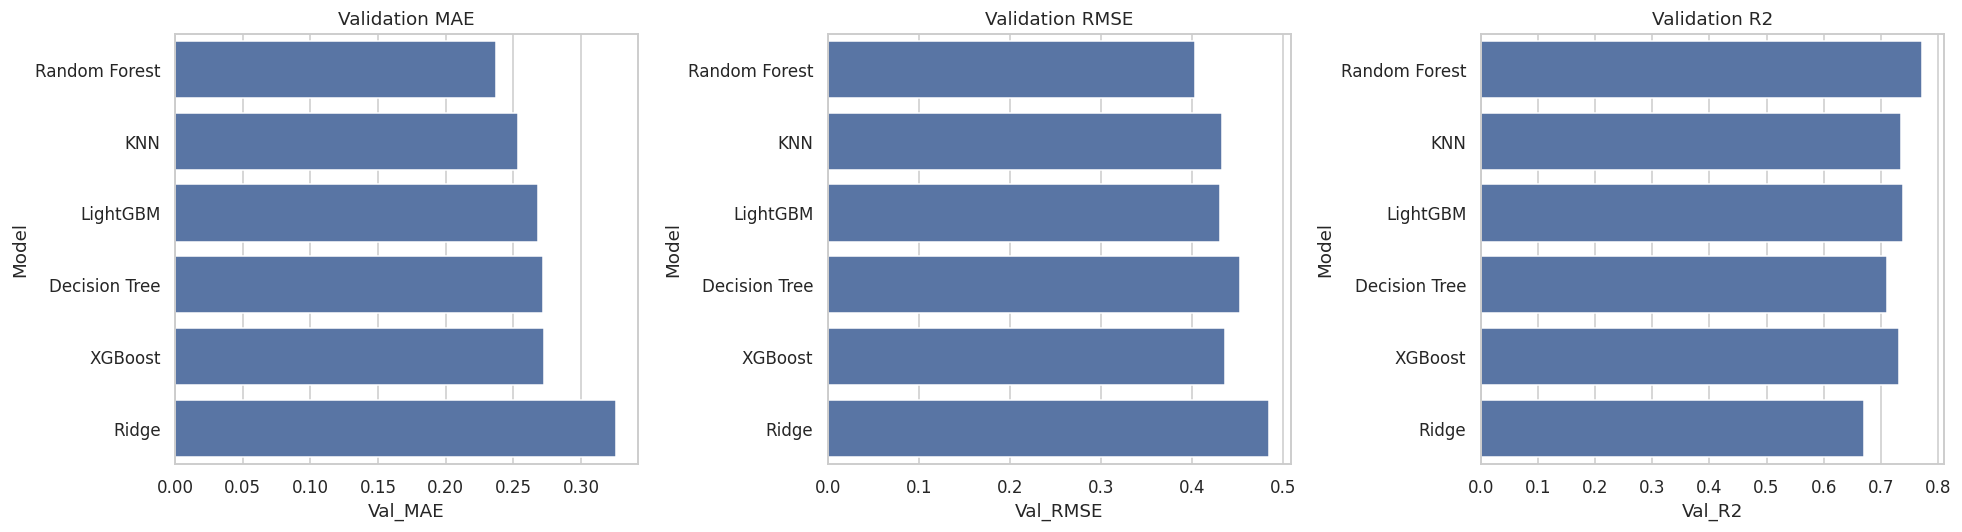

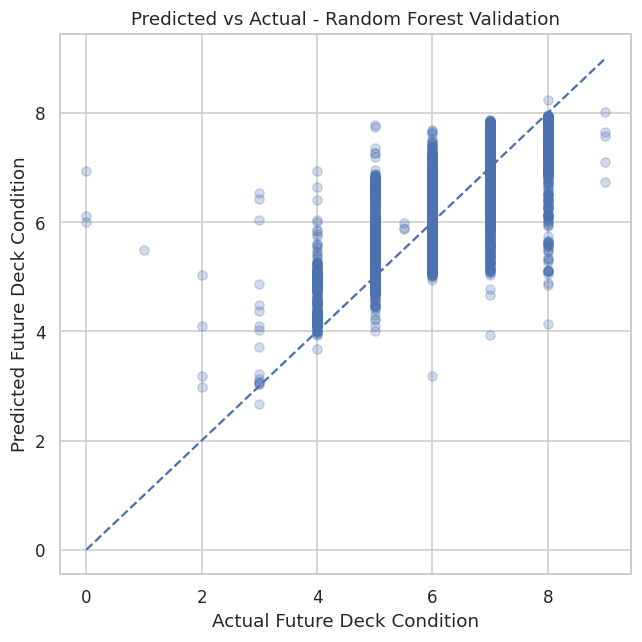

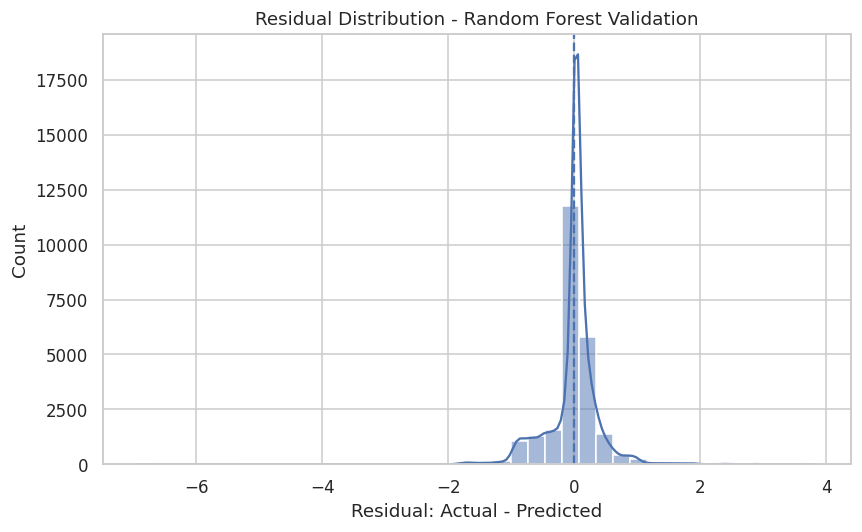

Validation residual mean: -0.0033
Validation residual standard deviation: 0.4025


In [ ]:
# ── Model Comparison Plots ────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=deck_results_df, x="Val_MAE", y="Model", ax=axes[0])
axes[0].set_title("Validation MAE")

sns.barplot(data=deck_results_df, x="Val_RMSE", y="Model", ax=axes[1])
axes[1].set_title("Validation RMSE")

sns.barplot(data=deck_results_df, x="Val_R2", y="Model", ax=axes[2])
axes[2].set_title("Validation R2")

plt.tight_layout()
plt.show()

best_val_pred = deck_predictions_val[best_deck_model_name]
best_holdout_pred = deck_predictions_holdout[best_deck_model_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_val_deck, best_val_pred, alpha=0.25)
plt.plot([y_val_deck.min(), y_val_deck.max()], [y_val_deck.min(), y_val_deck.max()], linestyle="--")
plt.xlabel("Actual Future Deck Condition")
plt.ylabel("Predicted Future Deck Condition")
plt.title(f"Predicted vs Actual - {best_deck_model_name} Validation")
plt.tight_layout()
plt.show()

residuals = y_val_deck - best_val_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual: Actual - Predicted")
plt.title(f"Residual Distribution - {best_deck_model_name} Validation")
plt.tight_layout()
plt.show()

print("Validation residual mean:", round(residuals.mean(), 4))
print("Validation residual standard deviation:", round(residuals.std(), 4))

# SHAP explainability

SHAP is applied to a tree-based model. If the best validation model is not tree-based, Random Forest is used for explanation because it is suitable for SHAP tree explanations.

SHAP model used: Random Forest


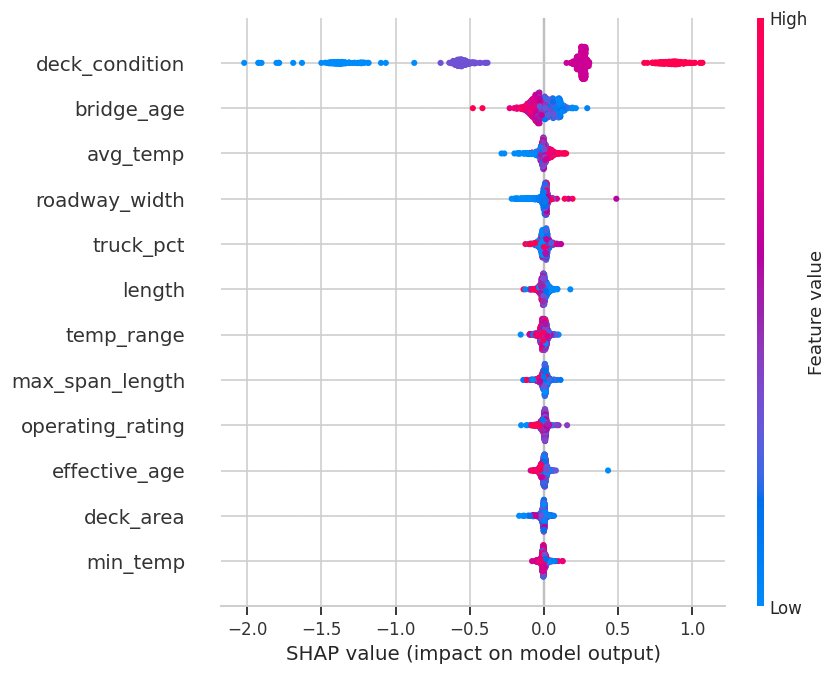

In [ ]:
# ── SHAP Explainability ──────────────────────────────────────────────────

shap_model_name = best_deck_model_name if best_deck_model_name in ["Decision Tree", "Random Forest", "XGBoost", "LightGBM"] else "Random Forest"
shap_model = trained_deck_models[shap_model_name]

# Tree models were trained on imputed, unscaled features
X_shap_source = X_val_imp.sample(n=min(1000, len(X_val_imp)), random_state=SEED)

print("SHAP model used:", shap_model_name)

try:
    explainer = shap.TreeExplainer(shap_model)
    shap_values = explainer.shap_values(X_shap_source)
    shap.summary_plot(shap_values, X_shap_source, show=True)
except Exception as e:
    print("SHAP could not be generated for this model.")
    print("Reason:", e)

# Multi-output classical modeling

Separate models are trained for future deck, superstructure, and substructure condition. For each target, the model with the lowest validation MAE is selected.

In [ ]:
# ── Train Best Classical Model for Each Component ─────────────────────────

component_names = {
    "deck_condition_future": "Deck",
    "super_condition_future": "Superstructure",
    "sub_condition_future": "Substructure"
}

all_component_results = []
best_component_models = {}
best_component_model_names = {}
best_component_holdout_preds = {}
best_component_val_preds = {}

for target in target_cols:
    y_train = train_df[target]
    y_val = val_df[target]
    y_holdout = holdout_df[target]

    target_results = []

    for name, template in model_templates.items():
        model = clone(template)

        if name in NEEDS_SCALING:
            Xtr, Xva, Xho = X_train_scaled, X_val_scaled, X_holdout_scaled
        else:
            Xtr, Xva, Xho = X_train_imp, X_val_imp, X_holdout_imp

        model.fit(Xtr, y_train)
        val_pred = model.predict(Xva)
        holdout_pred = model.predict(Xho)

        val_metrics = regression_metrics(y_val, val_pred)
        holdout_metrics = regression_metrics(y_holdout, holdout_pred)

        row = {
            "Component": component_names[target],
            "Target": target,
            "Model": name,
            "Val_MAE": val_metrics["MAE"],
            "Val_RMSE": val_metrics["RMSE"],
            "Val_R2": val_metrics["R2"],
            "Holdout_MAE": holdout_metrics["MAE"],
            "Holdout_RMSE": holdout_metrics["RMSE"],
            "Holdout_R2": holdout_metrics["R2"]
        }
        target_results.append(row)
        all_component_results.append(row)

    target_results_df = pd.DataFrame(target_results).sort_values("Val_MAE").reset_index(drop=True)
    best_name = target_results_df.loc[0, "Model"]
    best_component_model_names[target] = best_name

    # Retrain best model and save predictions
    best_model = clone(model_templates[best_name])
    if best_name in NEEDS_SCALING:
        Xtr, Xva, Xho = X_train_scaled, X_val_scaled, X_holdout_scaled
    else:
        Xtr, Xva, Xho = X_train_imp, X_val_imp, X_holdout_imp

    best_model.fit(Xtr, y_train)
    best_component_models[target] = best_model
    best_component_val_preds[target] = best_model.predict(Xva)
    best_component_holdout_preds[target] = best_model.predict(Xho)

component_results_df = pd.DataFrame(all_component_results)
print("All component model results:")
display(component_results_df.sort_values(["Component", "Val_MAE"]))

print("Best model per component:")
for target, name in best_component_model_names.items():
    print(component_names[target] + ":", name)

All component model results:


,Component,Target,Model,Val_MAE,Val_RMSE,Val_R2,Holdout_MAE,Holdout_RMSE,Holdout_R2
2,Deck,deck_condition_future,Random Forest,0.237173,0.402466,0.771754,0.433189,0.645439,0.123789
3,Deck,deck_condition_future,KNN,0.253076,0.432903,0.735925,0.424824,0.646003,0.122256
5,Deck,deck_condition_future,LightGBM,0.268332,0.429997,0.739460,0.427921,0.645912,0.122502
1,Deck,deck_condition_future,Decision Tree,0.272105,0.452741,0.711168,0.430006,0.656038,0.094774
4,Deck,deck_condition_future,XGBoost,0.272413,0.435835,0.732337,0.426924,0.644372,0.126681
0,Deck,deck_condition_future,Ridge,0.325929,0.484139,0.669719,0.433074,0.624674,0.179259
14,Substructure,sub_condition_future,Random Forest,0.388314,0.548311,0.689596,0.529794,0.703569,0.311087
17,Substructure,sub_condition_future,LightGBM,0.488300,0.655259,0.556699,0.548261,0.716667,0.285197
15,Substructure,sub_condition_future,KNN,0.493171,0.699215,0.495228,0.559623,0.749941,0.217281
16,Substructure,sub_condition_future,XGBoost,0.501744,0.671484,0.534474,0.562986,0.730573,0.257188


Best model per component:
Deck: Random Forest
Superstructure: Random Forest
Substructure: Random Forest


In [ ]:
# ── Final Classical Holdout Summary ───────────────────────────────────────

classical_best_rows = []
for target in target_cols:
    model_name = best_component_model_names[target]
    y_true = holdout_df[target]
    y_pred = best_component_holdout_preds[target]
    m = regression_metrics(y_true, y_pred)
    classical_best_rows.append({
        "Model_Group": "Best Classical ML",
        "Component": component_names[target],
        "Best_Model": model_name,
        "Holdout_MAE": m["MAE"],
        "Holdout_RMSE": m["RMSE"],
        "Holdout_R2": m["R2"]
    })

classical_best_summary = pd.DataFrame(classical_best_rows)
display(classical_best_summary)

avg_classical = classical_best_summary[["Holdout_MAE", "Holdout_RMSE", "Holdout_R2"]].mean()
print("Average classical ML holdout performance:")
print(avg_classical)

,Model_Group,Component,Best_Model,Holdout_MAE,Holdout_RMSE,Holdout_R2
0,Best Classical ML,Deck,Random Forest,0.433189,0.645439,0.123789
1,Best Classical ML,Superstructure,Random Forest,0.447973,0.619466,0.418821
2,Best Classical ML,Substructure,Random Forest,0.529794,0.703569,0.311087


Average classical ML holdout performance:
Holdout_MAE     0.470319
Holdout_RMSE    0.656158
Holdout_R2      0.284565
dtype: float64


# Maintenance urgency recommendation

The recommendation is based on the worst predicted future condition among deck, superstructure, and substructure.

- LOW: worst condition is 7 or higher
- MEDIUM: worst condition is 5 or 6
- HIGH: worst condition is 4 or lower

In [ ]:
# ── Maintenance Urgency Labels ───────────────────────────────────────────

def maintenance_urgency_from_values(deck, superstructure, substructure):
    worst_condition = min(deck, superstructure, substructure)

    if worst_condition <= 4:
        return "HIGH"
    elif worst_condition <= 6:
        return "MEDIUM"
    else:
        return "LOW"

def maintenance_urgency_from_array(arr):
    return maintenance_urgency_from_values(arr[0], arr[1], arr[2])

# Actual urgency from actual future condition values
actual_future_conditions = holdout_df[target_cols].values
actual_urgency = np.array([maintenance_urgency_from_array(row) for row in actual_future_conditions])

# Predicted urgency from best classical component predictions
pred_future_conditions = np.column_stack([
    best_component_holdout_preds["deck_condition_future"],
    best_component_holdout_preds["super_condition_future"],
    best_component_holdout_preds["sub_condition_future"]
])
pred_urgency = np.array([maintenance_urgency_from_array(row) for row in pred_future_conditions])

urgency_df = holdout_df[["bridge_id", "year", "target_year"]].copy()
urgency_df["actual_deck_future"] = holdout_df["deck_condition_future"].values
urgency_df["actual_super_future"] = holdout_df["super_condition_future"].values
urgency_df["actual_sub_future"] = holdout_df["sub_condition_future"].values
urgency_df["pred_deck_future"] = pred_future_conditions[:, 0]
urgency_df["pred_super_future"] = pred_future_conditions[:, 1]
urgency_df["pred_sub_future"] = pred_future_conditions[:, 2]
urgency_df["actual_urgency"] = actual_urgency
urgency_df["predicted_urgency"] = pred_urgency

print("Predicted maintenance urgency distribution:")
print(urgency_df["predicted_urgency"].value_counts())

print("\nActual maintenance urgency distribution:")
print(urgency_df["actual_urgency"].value_counts())

display(urgency_df.head())

Predicted maintenance urgency distribution:
predicted_urgency
LOW       20122
MEDIUM    11095
HIGH        320
Name: count, dtype: int64

Actual maintenance urgency distribution:
actual_urgency
LOW       17662
MEDIUM    12760
HIGH       1115
Name: count, dtype: int64


,bridge_id,year,target_year,actual_deck_future,actual_super_future,actual_sub_future,pred_deck_future,pred_super_future,pred_sub_future,actual_urgency,predicted_urgency
8,2GA1475,2014,2019,6.0,6.0,5.0,6.083930,6.062311,4.946120,MEDIUM,MEDIUM
9,2GA1475,2015,2020,6.0,6.0,5.0,6.134231,6.155921,4.981893,MEDIUM,MEDIUM
10,2GA1475,2016,2021,6.0,6.0,5.0,6.085027,6.058099,5.201300,MEDIUM,MEDIUM
11,2GA1475,2017,2022,6.0,6.0,6.0,6.109330,6.069736,4.884811,MEDIUM,MEDIUM
25,2GA1802,2014,2019,6.0,6.0,4.0,5.914849,5.804845,4.775213,HIGH,MEDIUM


Maintenance urgency classification report:
              precision    recall  f1-score   support

         LOW       0.74      0.84      0.78     17662
      MEDIUM       0.67      0.59      0.63     12760
        HIGH       0.84      0.24      0.38      1115

    accuracy                           0.72     31537
   macro avg       0.75      0.56      0.60     31537
weighted avg       0.71      0.72      0.71     31537

Accuracy: 0.715
Macro Precision: 0.7509
Macro Recall: 0.5553
Macro F1: 0.5955


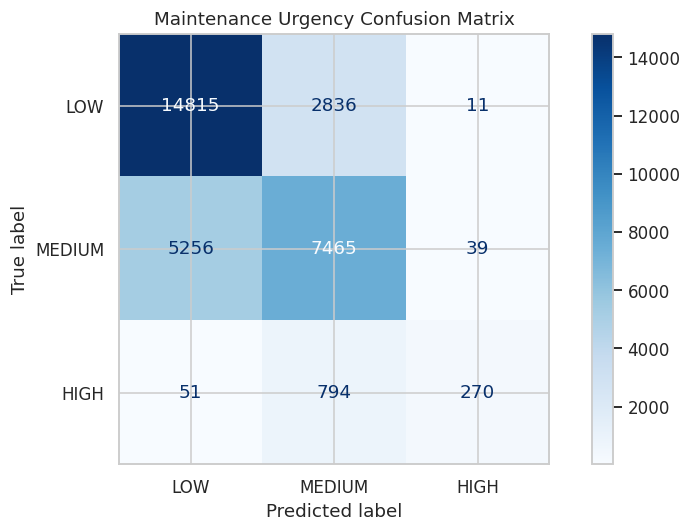

In [ ]:
# ── Maintenance Urgency Classification Evaluation ─────────────────────────

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

labels = ["LOW", "MEDIUM", "HIGH"]

print("Maintenance urgency classification report:")
print(classification_report(actual_urgency, pred_urgency, labels=labels, zero_division=0))

print("Accuracy:", round(accuracy_score(actual_urgency, pred_urgency), 4))
print("Macro Precision:", round(precision_score(actual_urgency, pred_urgency, labels=labels, average="macro", zero_division=0), 4))
print("Macro Recall:", round(recall_score(actual_urgency, pred_urgency, labels=labels, average="macro", zero_division=0), 4))
print("Macro F1:", round(f1_score(actual_urgency, pred_urgency, labels=labels, average="macro", zero_division=0), 4))

cm = confusion_matrix(actual_urgency, pred_urgency, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Maintenance Urgency Confusion Matrix")
plt.tight_layout()
plt.show()

# Per-bridge prediction function

In [ ]:
# ── Per-Bridge Classical ML Prediction Function ──────────────────────────

def predict_bridge_ml(bridge_id, query_year):
    match = df_model_base[
        (df_model_base["bridge_id"].astype(str) == str(bridge_id)) &
        (df_model_base["year"] == query_year)
    ].copy()

    if match.empty:
        print("No record found for bridge_id =", bridge_id, "and year =", query_year)
        return None

    row = match.iloc[[0]].copy()
    X_row_raw = row[final_features]
    X_row_imp = pd.DataFrame(model_imputer.transform(X_row_raw), columns=final_features)
    X_row_scaled = pd.DataFrame(model_scaler.transform(X_row_imp), columns=final_features)

    preds = {}
    for target in target_cols:
        model_name = best_component_model_names[target]
        model = best_component_models[target]
        X_input = X_row_scaled if model_name in NEEDS_SCALING else X_row_imp
        preds[target] = float(model.predict(X_input)[0])

    urgency = maintenance_urgency_from_values(
        preds["deck_condition_future"],
        preds["super_condition_future"],
        preds["sub_condition_future"]
    )

    print("Bridge ID:", bridge_id)
    print("Current year:", query_year)
    print("Target year:", query_year + FORECAST_YEARS)
    print("\nCurrent condition ratings:")
    print("Deck:", row["deck_condition"].iloc[0])
    print("Superstructure:", row["super_condition"].iloc[0])
    print("Substructure:", row["sub_condition"].iloc[0])

    print("\nPredicted future condition ratings:")
    print("Deck:", round(preds["deck_condition_future"], 2))
    print("Superstructure:", round(preds["super_condition_future"], 2))
    print("Substructure:", round(preds["sub_condition_future"], 2))
    print("\nMaintenance urgency:", urgency)

    actual_cols_available = row[target_cols].notna().all(axis=1).iloc[0]
    if actual_cols_available:
        print("\nActual future condition ratings:")
        print("Deck:", row["deck_condition_future"].iloc[0])
        print("Superstructure:", row["super_condition_future"].iloc[0])
        print("Substructure:", row["sub_condition_future"].iloc[0])

    return {
        "bridge_id": bridge_id,
        "query_year": query_year,
        "target_year": query_year + FORECAST_YEARS,
        "predictions": preds,
        "maintenance_urgency": urgency
    }

# Example usage:
# predict_bridge_ml("1GA3906", 2018)

# LSTM sequence model

The LSTM uses the past 15 years of bridge records to predict the future deck, superstructure, and substructure conditions after 5 years.

In [ ]:
# ── LSTM Imports and Configuration ───────────────────────────────────────

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEQ_LEN = 15
LSTM_TARGET_HORIZON = FORECAST_YEARS
BATCH_SIZE = 256
LSTM_EPOCHS = 40
LSTM_LR = 0.001

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Sequence length:", SEQ_LEN)
print("Forecast horizon:", LSTM_TARGET_HORIZON)

Device: cpu
Sequence length: 15
Forecast horizon: 5


In [ ]:
# ── Build LSTM Sequences ─────────────────────────────────────────────────

# Use the same final selected features for the sequence model
sequence_features = final_features.copy()

seq_df = df_model_base.sort_values(["bridge_id", "year"]).copy()

X_sequences = []
y_sequences = []
seq_bridge_ids = []
seq_current_years = []
seq_target_years = []

for bridge_id, group in seq_df.groupby("bridge_id"):
    group = group.sort_values("year").reset_index(drop=True)

    for i in range(SEQ_LEN - 1, len(group)):
        current_row = group.iloc[i]

        # The current row must have future targets available
        if current_row[target_cols].isna().any():
            continue

        seq_window = group.iloc[i - SEQ_LEN + 1:i + 1]

        # Require exactly continuous years inside the input window
        years = seq_window["year"].values
        if not np.all(np.diff(years) == 1):
            continue

        X_sequences.append(seq_window[sequence_features].values)
        y_sequences.append(current_row[target_cols].values.astype(float))
        seq_bridge_ids.append(bridge_id)
        seq_current_years.append(current_row["year"])
        seq_target_years.append(current_row["target_year"])

X_sequences = np.array(X_sequences, dtype=float)
y_sequences = np.array(y_sequences, dtype=float)
seq_meta = pd.DataFrame({
    "bridge_id": seq_bridge_ids,
    "year": seq_current_years,
    "target_year": seq_target_years
})

print("X_sequences shape:", X_sequences.shape)
print("y_sequences shape:", y_sequences.shape)
print("Sequence metadata shape:", seq_meta.shape)

X_sequences shape: (42578, 15, 12)
y_sequences shape: (42578, 3)
Sequence metadata shape: (42578, 3)


In [ ]:
# ── LSTM Temporal Split and Scaling ──────────────────────────────────────

trainval_seq_mask = seq_meta["year"] < HOLDOUT_START_YEAR
holdout_seq_mask = seq_meta["year"] >= HOLDOUT_START_YEAR

X_seq_trainval = X_sequences[trainval_seq_mask.values]
y_seq_trainval = y_sequences[trainval_seq_mask.values]
meta_trainval = seq_meta[trainval_seq_mask.values].reset_index(drop=True)

X_seq_holdout = X_sequences[holdout_seq_mask.values]
y_seq_holdout = y_sequences[holdout_seq_mask.values]
meta_holdout_seq = seq_meta[holdout_seq_mask.values].reset_index(drop=True)

train_idx, val_idx = train_test_split(
    np.arange(len(X_seq_trainval)),
    test_size=0.20,
    random_state=SEED
)

X_seq_train = X_seq_trainval[train_idx]
y_seq_train = y_seq_trainval[train_idx]
X_seq_val = X_seq_trainval[val_idx]
y_seq_val = y_seq_trainval[val_idx]

# Impute and scale sequence features using training data only
seq_imputer = SimpleImputer(strategy="median")
seq_scaler = StandardScaler()

n_features_seq = X_seq_train.shape[2]

X_seq_train_2d = X_seq_train.reshape(-1, n_features_seq)
X_seq_val_2d = X_seq_val.reshape(-1, n_features_seq)
X_seq_holdout_2d = X_seq_holdout.reshape(-1, n_features_seq)

X_seq_train_imp = seq_imputer.fit_transform(X_seq_train_2d)
X_seq_val_imp = seq_imputer.transform(X_seq_val_2d)
X_seq_holdout_imp = seq_imputer.transform(X_seq_holdout_2d)

X_seq_train_scaled = seq_scaler.fit_transform(X_seq_train_imp).reshape(X_seq_train.shape)
X_seq_val_scaled = seq_scaler.transform(X_seq_val_imp).reshape(X_seq_val.shape)
X_seq_holdout_scaled = seq_scaler.transform(X_seq_holdout_imp).reshape(X_seq_holdout.shape)

print("LSTM train:", X_seq_train_scaled.shape, y_seq_train.shape)
print("LSTM validation:", X_seq_val_scaled.shape, y_seq_val.shape)
print("LSTM holdout:", X_seq_holdout_scaled.shape, y_seq_holdout.shape)

LSTM train: (11022, 15, 12) (11022, 3)
LSTM validation: (2756, 15, 12) (2756, 3)
LSTM holdout: (28800, 15, 12) (28800, 3)


In [ ]:
# ── PyTorch Dataset and DataLoaders ──────────────────────────────────────

class BridgeSequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_seq_loader = DataLoader(
    BridgeSequenceDataset(X_seq_train_scaled, y_seq_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_seq_loader = DataLoader(
    BridgeSequenceDataset(X_seq_val_scaled, y_seq_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

holdout_seq_loader = DataLoader(
    BridgeSequenceDataset(X_seq_holdout_scaled, y_seq_holdout),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# ── LSTM Model Architecture ──────────────────────────────────────────────

class BridgeLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.20, output_size=3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.fc(last_hidden)

lstm_model = BridgeLSTM(input_size=len(sequence_features)).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

print(lstm_model)
print("Trainable parameters:", sum(p.numel() for p in lstm_model.parameters() if p.requires_grad))

BridgeLSTM(
  (lstm): LSTM(12, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable parameters: 213251


Epoch 001/40 | Train MSE: 17.0962 | Val MSE: 0.9693
Epoch 005/40 | Train MSE: 1.0249 | Val MSE: 0.7102
Epoch 010/40 | Train MSE: 0.9510 | Val MSE: 0.7187
Epoch 015/40 | Train MSE: 0.7764 | Val MSE: 0.5485
Epoch 020/40 | Train MSE: 0.6595 | Val MSE: 0.4519
Epoch 025/40 | Train MSE: 0.6444 | Val MSE: 0.4410
Epoch 030/40 | Train MSE: 0.6216 | Val MSE: 0.4297
Epoch 035/40 | Train MSE: 0.6101 | Val MSE: 0.4310
Epoch 040/40 | Train MSE: 0.6140 | Val MSE: 0.4256
Best validation MSE: 0.4256


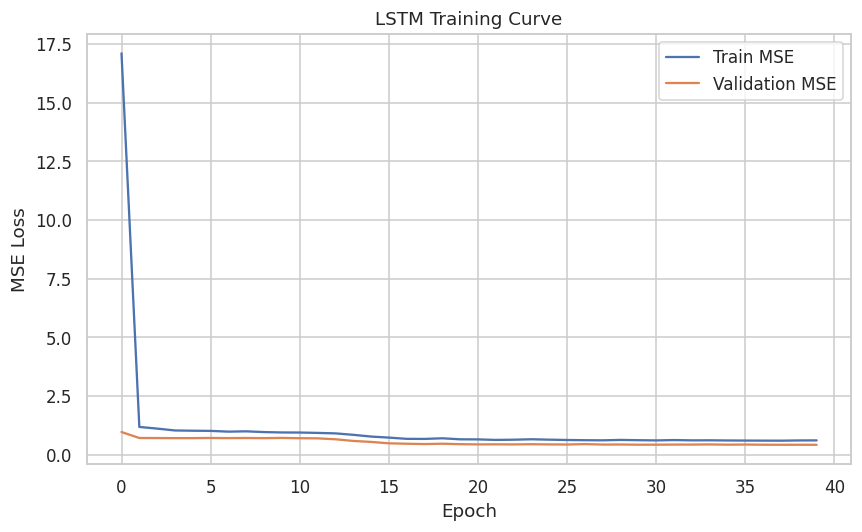

In [ ]:
# ── Train LSTM ───────────────────────────────────────────────────────────

best_val_loss = np.inf
best_lstm_state = None
train_losses = []
val_losses = []

for epoch in range(1, LSTM_EPOCHS + 1):
    lstm_model.train()
    batch_train_losses = []

    for xb, yb in train_seq_loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()
        preds = lstm_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_train_losses.append(loss.item())

    train_loss = float(np.mean(batch_train_losses))

    lstm_model.eval()
    batch_val_losses = []
    with torch.no_grad():
        for xb, yb in val_seq_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            preds = lstm_model(xb)
            loss = criterion(preds, yb)
            batch_val_losses.append(loss.item())

    val_loss = float(np.mean(batch_val_losses))
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_lstm_state = {k: v.cpu().clone() for k, v in lstm_model.state_dict().items()}

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:03d}/{LSTM_EPOCHS} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

lstm_model.load_state_dict(best_lstm_state)
print("Best validation MSE:", round(best_val_loss, 4))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

LSTM results:


,Model_Group,Component,Val_MAE,Val_RMSE,Val_R2,Holdout_MAE,Holdout_RMSE,Holdout_R2
0,LSTM,Deck,0.414520,0.556976,0.471698,0.486859,0.652671,0.127105
1,LSTM,Superstructure,0.506378,0.665950,0.419862,0.529260,0.697387,0.255198
2,LSTM,Substructure,0.563303,0.722890,0.327818,0.632537,0.809494,0.112268


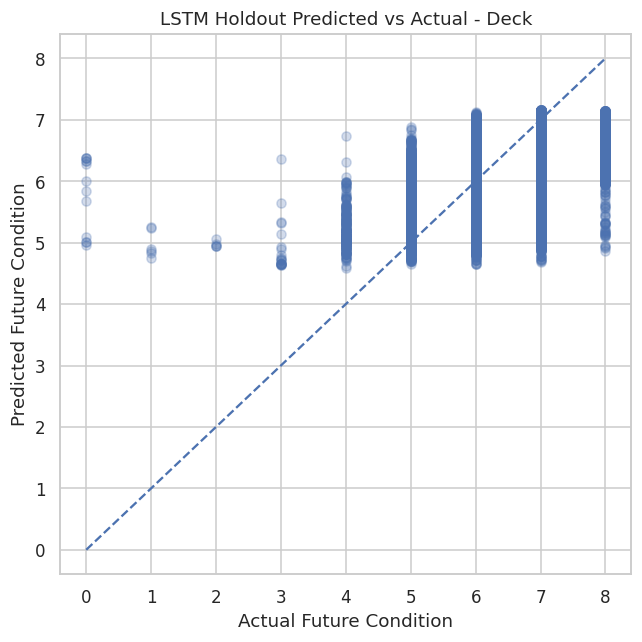

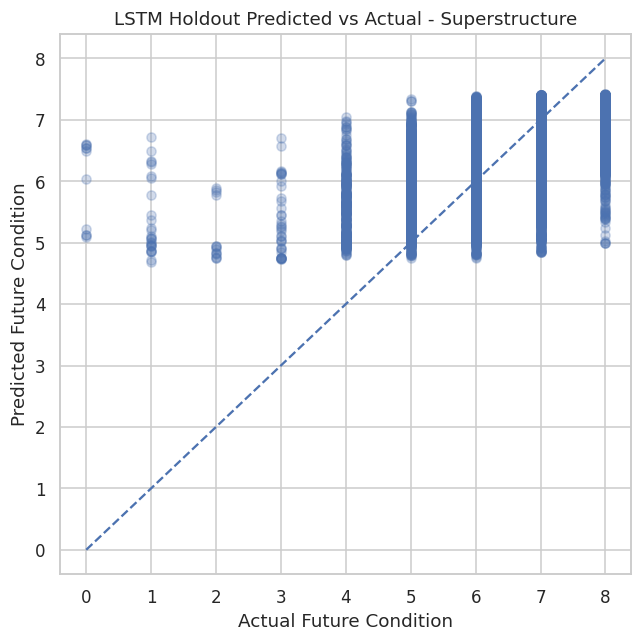

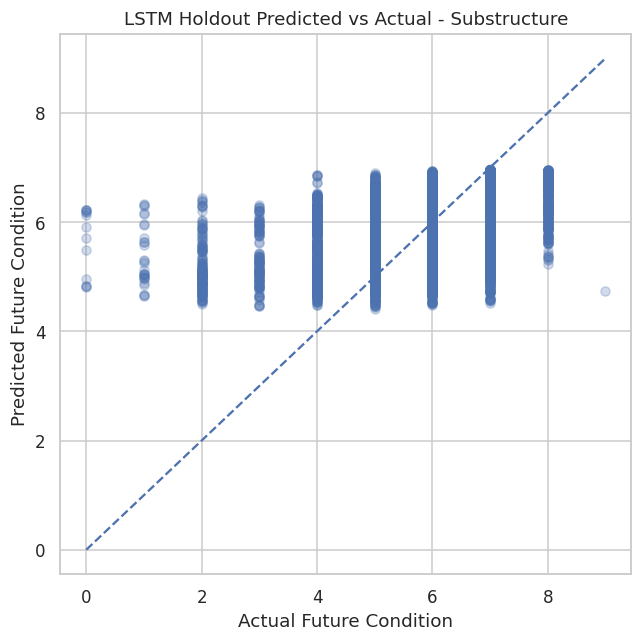

In [ ]:
# ── Evaluate LSTM ────────────────────────────────────────────────────────

def predict_lstm(loader):
    lstm_model.eval()
    preds_list = []
    true_list = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            preds = lstm_model(xb).cpu().numpy()
            preds_list.append(preds)
            true_list.append(yb.numpy())

    return np.vstack(preds_list), np.vstack(true_list)

lstm_val_preds, lstm_val_true = predict_lstm(val_seq_loader)
lstm_holdout_preds, lstm_holdout_true = predict_lstm(holdout_seq_loader)

lstm_rows = []
for i, component in enumerate(["Deck", "Superstructure", "Substructure"]):
    val_m = regression_metrics(lstm_val_true[:, i], lstm_val_preds[:, i])
    ho_m = regression_metrics(lstm_holdout_true[:, i], lstm_holdout_preds[:, i])

    lstm_rows.append({
        "Model_Group": "LSTM",
        "Component": component,
        "Val_MAE": val_m["MAE"],
        "Val_RMSE": val_m["RMSE"],
        "Val_R2": val_m["R2"],
        "Holdout_MAE": ho_m["MAE"],
        "Holdout_RMSE": ho_m["RMSE"],
        "Holdout_R2": ho_m["R2"]
    })

lstm_summary = pd.DataFrame(lstm_rows)
print("LSTM results:")
display(lstm_summary)

for i, component in enumerate(["Deck", "Superstructure", "Substructure"]):
    plt.figure(figsize=(6, 6))
    plt.scatter(lstm_holdout_true[:, i], lstm_holdout_preds[:, i], alpha=0.25)
    plt.plot([lstm_holdout_true[:, i].min(), lstm_holdout_true[:, i].max()],
             [lstm_holdout_true[:, i].min(), lstm_holdout_true[:, i].max()], linestyle="--")
    plt.xlabel("Actual Future Condition")
    plt.ylabel("Predicted Future Condition")
    plt.title(f"LSTM Holdout Predicted vs Actual - {component}")
    plt.tight_layout()
    plt.show()

LSTM maintenance urgency classification report:
              precision    recall  f1-score   support

         LOW       0.67      0.89      0.77     15295
      MEDIUM       0.69      0.47      0.56     12405
        HIGH       0.00      0.00      0.00      1100

    accuracy                           0.68     28800
   macro avg       0.45      0.45      0.44     28800
weighted avg       0.65      0.68      0.65     28800

Accuracy: 0.6769
Macro Precision: 0.4547
Macro Recall: 0.4546
Macro F1: 0.4423


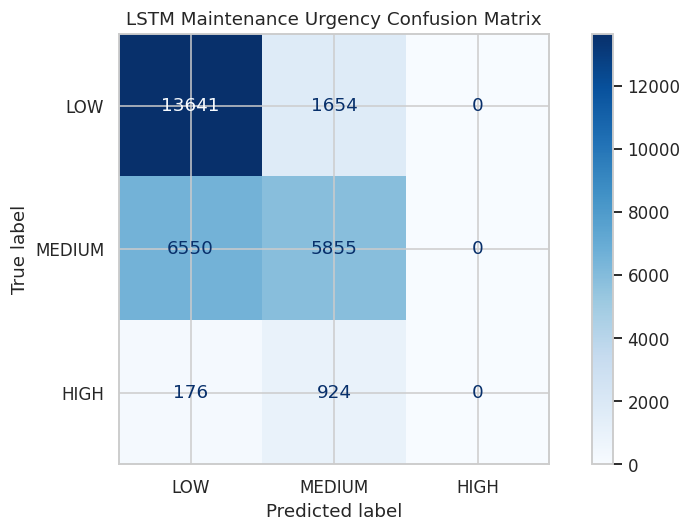

In [ ]:
# ── LSTM Maintenance Urgency Evaluation ─────────────────────────────────

lstm_actual_urgency = np.array([maintenance_urgency_from_array(row) for row in lstm_holdout_true])
lstm_pred_urgency = np.array([maintenance_urgency_from_array(row) for row in lstm_holdout_preds])

print("LSTM maintenance urgency classification report:")
print(classification_report(lstm_actual_urgency, lstm_pred_urgency, labels=labels, zero_division=0))

print("Accuracy:", round(accuracy_score(lstm_actual_urgency, lstm_pred_urgency), 4))
print("Macro Precision:", round(precision_score(lstm_actual_urgency, lstm_pred_urgency, labels=labels, average="macro", zero_division=0), 4))
print("Macro Recall:", round(recall_score(lstm_actual_urgency, lstm_pred_urgency, labels=labels, average="macro", zero_division=0), 4))
print("Macro F1:", round(f1_score(lstm_actual_urgency, lstm_pred_urgency, labels=labels, average="macro", zero_division=0), 4))

cm_lstm = confusion_matrix(lstm_actual_urgency, lstm_pred_urgency, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("LSTM Maintenance Urgency Confusion Matrix")
plt.tight_layout()
plt.show()

# Final comparison

In [ ]:
# ── Final Comparison: Classical ML vs LSTM ───────────────────────────────

classical_for_compare = classical_best_summary.copy()
classical_for_compare["Val_MAE"] = np.nan
classical_for_compare["Val_RMSE"] = np.nan
classical_for_compare["Val_R2"] = np.nan
classical_for_compare = classical_for_compare[[
    "Model_Group", "Component", "Val_MAE", "Val_RMSE", "Val_R2",
    "Holdout_MAE", "Holdout_RMSE", "Holdout_R2"
]]

lstm_for_compare = lstm_summary[[
    "Model_Group", "Component", "Val_MAE", "Val_RMSE", "Val_R2",
    "Holdout_MAE", "Holdout_RMSE", "Holdout_R2"
]].copy()

final_comparison = pd.concat([classical_for_compare, lstm_for_compare], ignore_index=True)
display(final_comparison)

final_average_summary = final_comparison.groupby("Model_Group")[[
    "Holdout_MAE", "Holdout_RMSE", "Holdout_R2"
]].mean().reset_index().sort_values("Holdout_MAE")

print("Average holdout performance by model group:")
display(final_average_summary)

plt.figure(figsize=(8, 5))
sns.barplot(data=final_average_summary, x="Model_Group", y="Holdout_MAE")
plt.title("Average Holdout MAE: Classical ML vs LSTM")
plt.xlabel("Model Group")
plt.ylabel("Average Holdout MAE")
plt.tight_layout()
plt.show()

In [ ]:
# ── LSTM Per-Bridge Prediction Function ─────────────────────────────────

def predict_bridge_lstm(bridge_id, query_year):
    group = df_model_base[df_model_base["bridge_id"].astype(str) == str(bridge_id)].sort_values("year").copy()

    if group.empty:
        print("No records found for bridge_id =", bridge_id)
        return None

    end_rows = group[group["year"] == query_year]
    if end_rows.empty:
        print("No record found for bridge_id =", bridge_id, "and year =", query_year)
        return None

    end_position = group.index.get_loc(end_rows.index[0])
    group_reset = group.reset_index(drop=True)
    end_position = group_reset[group_reset["year"] == query_year].index[0]

    if end_position < SEQ_LEN - 1:
        print("Not enough previous records for a", SEQ_LEN, "year LSTM sequence.")
        return None

    seq_window = group_reset.iloc[end_position - SEQ_LEN + 1:end_position + 1]

    if not np.all(np.diff(seq_window["year"].values) == 1):
        print("The required", SEQ_LEN, "year window is not continuous.")
        return None

    X_seq = seq_window[sequence_features].values.astype(float).reshape(1, SEQ_LEN, len(sequence_features))
    X_seq_2d = X_seq.reshape(-1, len(sequence_features))
    X_seq_imp = seq_imputer.transform(X_seq_2d)
    X_seq_scaled = seq_scaler.transform(X_seq_imp).reshape(1, SEQ_LEN, len(sequence_features))

    lstm_model.eval()
    with torch.no_grad():
        pred = lstm_model(torch.tensor(X_seq_scaled, dtype=torch.float32).to(DEVICE)).cpu().numpy()[0]

    urgency = maintenance_urgency_from_array(pred)

    print("Bridge ID:", bridge_id)
    print("Sequence years:", int(seq_window["year"].min()), "to", int(seq_window["year"].max()))
    print("Target year:", query_year + FORECAST_YEARS)
    print("\nLSTM predicted future condition ratings:")
    print("Deck:", round(float(pred[0]), 2))
    print("Superstructure:", round(float(pred[1]), 2))
    print("Substructure:", round(float(pred[2]), 2))
    print("\nMaintenance urgency:", urgency)

    current_row = group_reset.iloc[end_position]
    if current_row[target_cols].notna().all():
        print("\nActual future condition ratings:")
        print("Deck:", current_row["deck_condition_future"])
        print("Superstructure:", current_row["super_condition_future"])
        print("Substructure:", current_row["sub_condition_future"])

    return {
        "bridge_id": bridge_id,
        "query_year": query_year,
        "target_year": query_year + FORECAST_YEARS,
        "lstm_predictions": {
            "deck_condition_future": float(pred[0]),
            "super_condition_future": float(pred[1]),
            "sub_condition_future": float(pred[2])
        },
        "maintenance_urgency": urgency
    }

# Example usage:
# predict_bridge_lstm("1GA3906", 2018)